# Sepsis Transportability — Q1 FINAL analysis

Bu final sürüm self-contained çalışır: Set A ve Set B klasörlerini bulur, veriyi okur, modelleri yeniden üretir ve yayın analizlerini çalıştırır.

**Final koşu:** `FAST_MODE = False` ayarlıdır. Tüm güven aralıkları ve örneklem-eğrisi tekrarları yayın ayarlarında çalışır.

Ana analizler: LR, HGB ve temporal HGB; transportability; calibration/BSS/AUPRC lift; patient-level measurement-process shift; common-support diagnostikleri; target-native recoverability; missingness ablation; local adaptation hierarchy; recalibration sample-size curve; clinical alert metrics; official PhysioNet/CinC normalized utility; patient-level decision curve; subgroup heterogeneity; publication figures/tables.

**Önemli metodolojik karar:** A ve B arasında patient-level measurement-process özelliklerinde neredeyse tam ayrışma bulunduğu için inverse-probability/entropy reweighting ile "shift decomposition" yapılmaz. Bunun yerine overlap eksikliği doğrudan raporlanır ve geri kazanılabilirlik target-native cross-validation ile ölçülür.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, time, json, sys
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
warnings.filterwarnings("ignore")

# --- Çalışma modu ---
FAST_MODE = False  # FINAL yayın koşusu
N_BOOT = 200 if FAST_MODE else 1000
N_BOOT_SG = 150 if FAST_MODE else 500
REPS_LC = 40 if FAST_MODE else 200
SEED = 2026
OUT = Path("q1_outputs_v2"); OUT.mkdir(exist_ok=True)
TABLES, FIGS = {}, {}

# --- Veri klasörlerini otomatik bul ---
def first_existing(cands):
    for p in cands:
        if p.exists() and any(p.glob("*.psv")):
            return p
    return None

A_DIR = first_existing([
    Path.home()/"İndirilenler"/"training_setA"/"training",
    Path.home()/"Downloads"/"training_setA"/"training",
    Path.cwd()/"training_setA"/"training",
])
B_DIR = first_existing([
    Path.home()/"İndirilenler"/"training_setB"/"training_setB",
    Path.home()/"İndirilenler"/"training_setB"/"training",
    Path.home()/"Downloads"/"training_setB"/"training_setB",
    Path.home()/"Downloads"/"training_setB"/"training",
    Path.cwd()/"training_setB"/"training_setB",
    Path.cwd()/"training_setB"/"training",
])
if A_DIR is None or B_DIR is None:
    raise FileNotFoundError(
        "training_setA/training veya training_setB klasörü bulunamadı. "
        "ZIP'leri daha önce açtığınız İndirilenler klasörünü kontrol edin."
    )
print("Set A:", A_DIR)
print("Set B:", B_DIR)

# --- Veriyi oku ---
def read_psv_folder(folder, hospital):
    files = sorted(folder.glob("*.psv"))
    chunks = []
    print(f"{hospital} okunuyor. Hasta dosyası: {len(files)}")
    for i, f in enumerate(files, 1):
        d = pd.read_csv(f, sep="|")
        d["patient_id"] = f.stem
        d["hospital"] = hospital
        chunks.append(d)
        if i % 2000 == 0:
            print(f"  {i} hasta okundu")
    out = pd.concat(chunks, ignore_index=True)
    print(f"{hospital} tamam: {out.patient_id.nunique()} hasta, {len(out)} saatlik kayıt")
    return out

A_data = read_psv_folder(A_DIR, "A")
B_data = read_psv_folder(B_DIR, "B")

# --- Yardımcılar ---
def logit(p):
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def expit(z):
    return 1.0 / (1.0 + np.exp(-z))

def cal_slope(y, p):
    lr = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return float(lr.coef_[0][0])

def cal_intercept_citl(y, p):
    """Calibration-in-the-large: slope=1 sabit, yalnızca intercept (offset)."""
    lp = logit(p); a = 0.0; y = np.asarray(y, float)
    def ll(a_):
        z = a_ + lp
        return float((y * z - np.logaddexp(0, z)).sum())
    cur = ll(a)
    for _ in range(100):
        q = expit(a + lp)
        g = (y - q).sum(); h = (q * (1 - q)).sum()
        if h <= 0: break
        step = g / h
        while abs(step) > 1e-12:
            new = ll(a + step)
            if new >= cur - 1e-12:
                a, cur = a + step, new
                break
            step /= 2
        if abs(step) < 1e-9: break
    return float(np.clip(a, -15, 15))

def ece(y, p, n_bins=10):
    p = np.asarray(p); y = np.asarray(y, float)
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    # Tekrarlanan quantile kenarlarına karşı güvenli.
    edges = np.maximum.accumulate(edges)
    b = np.clip(np.searchsorted(edges[1:-1], p, side="right"), 0, n_bins - 1)
    e = 0.0
    for k in range(n_bins):
        m = b == k
        if m.any(): e += m.mean() * abs(p[m].mean() - y[m].mean())
    return float(e)

def net_benefit(y, p, t):
    y = np.asarray(y); pred = np.asarray(p) >= t; n = len(y)
    tp = (pred & (y == 1)).sum(); fp = (pred & (y == 0)).sum()
    return tp / n - fp / n * t / (1 - t)

def metrics(y, p, with_cal=True):
    y = np.asarray(y).astype(int); p = np.asarray(p, float)
    prev = y.mean(); brier = brier_score_loss(y, p); null = prev * (1 - prev)
    ap = average_precision_score(y, p)
    d = dict(AUROC=roc_auc_score(y, p), AUPRC=ap, AUPRC_lift=ap / prev,
             Brier=brier, BSS=1 - brier / null, PO_ratio=p.mean() / prev,
             ECE=ece(y, p), Prev=prev)
    if with_cal:
        d["Slope"] = cal_slope(y, p); d["CITL"] = cal_intercept_citl(y, p)
    return d

class PatientBoot:
    """Hasta düzeyi bootstrap: her hastanın tüm saatleri blok halinde kalır."""
    def __init__(self, patient_ids):
        pid = np.asarray(patient_ids); order = np.argsort(pid, kind="stable"); sp = pid[order]
        starts = np.r_[0, np.flatnonzero(sp[1:] != sp[:-1]) + 1]
        ends = np.r_[starts[1:], len(sp)]
        self.blocks = [order[s:e] for s, e in zip(starts, ends)]
        self.n = len(self.blocks)
    def sample(self, rng):
        idx = rng.integers(0, self.n, self.n)
        return np.concatenate([self.blocks[i] for i in idx])

def boot_ci(pids, fn, n_boot=None, seed=SEED, label=""):
    if n_boot is None: n_boot = N_BOOT
    pb = PatientBoot(pids); rng = np.random.default_rng(seed)
    point = fn(np.arange(len(pids))); rows = []; t0 = time.time()
    for _ in range(n_boot):
        try: rows.append(fn(pb.sample(rng)))
        except (ValueError, ZeroDivisionError): continue
    df = pd.DataFrame(rows)
    out = pd.DataFrame({"point": pd.Series(point), "lo": df.quantile(.025), "hi": df.quantile(.975)})
    if label: print(f"  {label}: {len(rows)} resample, {time.time()-t0:.0f}s")
    return out

def fmt(df, dec=3):
    return df.apply(lambda r: f"{r.point:.{dec}f} ({r.lo:.{dec}f}–{r.hi:.{dec}f})", axis=1)

def lr_pipeline(add_indicator=True):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=add_indicator, keep_empty_features=True)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500, solver="lbfgs"))])

def hgb():
    return HistGradientBoostingClassifier(learning_rate=0.05, max_iter=150, max_leaf_nodes=31,
                                          l2_regularization=1.0, early_stopping=False, random_state=42)

class NonConstantSelector(BaseEstimator, TransformerMixin):
    """Her fit'te tamamen boş/sabit sütunları güvenle çıkarır (CV foldlarında HGB binning hatasını önler)."""
    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.keep_ = [c for c in Xdf.columns if Xdf[c].dropna().nunique() >= 2]
        if not self.keep_:
            raise ValueError("HGB için değişken kalan sütun yok.")
        return self
    def transform(self, X):
        Xdf = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        return Xdf[self.keep_]

def hgb_safe():
    return Pipeline([("selector", NonConstantSelector()), ("model", hgb())])

# --- Aynı Part 1 hasta bölmesi: A %80 eğitim / %20 iç doğrulama ---
drop_cols = ["SepsisLabel", "patient_id", "hospital"]
features = [c for c in A_data.columns if c not in drop_cols]
splitter_A = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(splitter_A.split(A_data, groups=A_data["patient_id"]))
A_train, A_val = A_data.iloc[train_idx].copy(), A_data.iloc[val_idx].copy()
print("A_train hasta:", A_train.patient_id.nunique(), "| A_val hasta:", A_val.patient_id.nunique())

# LR
model = lr_pipeline().fit(A_train[features], A_train["SepsisLabel"])
p_A = model.predict_proba(A_val[features])[:, 1]
p_B = model.predict_proba(B_data[features])[:, 1]

# HGB: kaynak eğitimde tamamen boş/sabit değişkenleri çıkar
hgb_features = [c for c in features if A_train[c].dropna().nunique() >= 2]
print("HGB özellik:", len(hgb_features), "| çıkarılan:", [c for c in features if c not in hgb_features])
hgb_model = hgb().fit(A_train[hgb_features], A_train["SepsisLabel"])
p_A_hgb = hgb_model.predict_proba(A_val[hgb_features])[:, 1]
p_B_hgb = hgb_model.predict_proba(B_data[hgb_features])[:, 1]

# --- Set B: %30 local adaptation / %70 bağımsız test ---
splitter_B = GroupShuffleSplit(n_splits=1, test_size=0.70, random_state=42)
cal_idx, test_idx = next(splitter_B.split(B_data, groups=B_data["patient_id"]))
B_cal, B_test = B_data.iloc[cal_idx].copy(), B_data.iloc[test_idx].copy()

yA_val = A_val["SepsisLabel"].to_numpy(); yB_all = B_data["SepsisLabel"].to_numpy()
pidA_val = A_val["patient_id"].to_numpy(); pidB_all = B_data["patient_id"].to_numpy()
y_cal = B_cal["SepsisLabel"].to_numpy(); y_test = B_test["SepsisLabel"].to_numpy()
pid_cal = B_cal["patient_id"].to_numpy(); pid_test = B_test["patient_id"].to_numpy()
print("B_cal hasta:", B_cal.patient_id.nunique(), "| B_test hasta:", B_test.patient_id.nunique())
print("Kurulum tamam. FAST_MODE =", FAST_MODE)


Set A: /home/omer/İndirilenler/training_setA/training
Set B: /home/omer/İndirilenler/training_setB/training_setB
A okunuyor. Hasta dosyası: 20336
  2000 hasta okundu
  4000 hasta okundu
  6000 hasta okundu
  8000 hasta okundu
  10000 hasta okundu
  12000 hasta okundu
  14000 hasta okundu
  16000 hasta okundu
  18000 hasta okundu
  20000 hasta okundu
A tamam: 20336 hasta, 790215 saatlik kayıt
B okunuyor. Hasta dosyası: 20000
  2000 hasta okundu
  4000 hasta okundu
  6000 hasta okundu
  8000 hasta okundu
  10000 hasta okundu
  12000 hasta okundu
  14000 hasta okundu
  16000 hasta okundu
  18000 hasta okundu
  20000 hasta okundu
B tamam: 20000 hasta, 761995 saatlik kayıt
A_train hasta: 16268 | A_val hasta: 4068
HGB özellik: 39 | çıkarılan: ['EtCO2']
B_cal hasta: 6000 | B_test hasta: 14000
Kurulum tamam. FAST_MODE = False


In [15]:
print(
    "cal_intercept_citl:",
    "HAZIR ✅" if "cal_intercept_citl" in globals() else "EKSİK ❌"
)

cal_intercept_citl: HAZIR ✅


In [3]:
STATIC = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]
MEASURED = [c for c in features if c not in STATIC]  # vital + lab (EtCO2 dahil)

def table1_block(df, name):
    g = df.groupby("patient_id")
    pt = g.agg(sepsis=("SepsisLabel", "max"), age=("Age", "first"), male=("Gender", "first"),
               los=("ICULOS", "max"), hospadm=("HospAdmTime", "first"),
               unit1=("Unit1", "first"), unit2=("Unit2", "first"))
    sep = df[df.SepsisLabel == 1].groupby("patient_id")["ICULOS"].min()
    s = pd.Series({
        "Patients": len(pt), "Hourly records": len(df),
        "Sepsis patients (%)": 100 * pt.sepsis.mean(),
        "Sepsis-positive hours (%)": 100 * df.SepsisLabel.mean(),
        "Age, mean (SD)": f"{pt.age.mean():.1f} ({pt.age.std():.1f})",
        "Male (%)": 100 * pt.male.mean(),
        "ICU LOS h, median (IQR)": f"{pt.los.median():.0f} ({pt.los.quantile(.25):.0f}–{pt.los.quantile(.75):.0f})",
        "HospAdmTime h, median (IQR)": f"{pt.hospadm.median():.1f} ({pt.hospadm.quantile(.25):.1f}–{pt.hospadm.quantile(.75):.1f})",
        "Unit1/Unit2 missing (%)": 100 * pt.unit1.isna().mean(),
        "Unit1=MICU (% of known)": 100 * pt.unit1.dropna().mean(),
        "First label hour, median (septic)": sep.median(),
        "Records per patient, median": g.size().median(),
    }, name=name)
    return s

TABLES["table1"] = pd.concat([table1_block(A_data, "Set A"), table1_block(B_data, "Set B")], axis=1)
display(TABLES["table1"])

# Değişken bazlı ölçüm sıklığı: satır başına ölçülme oranı ve hasta başına 24 saatte ölçüm sayısı
def measurement_profile(df, name):
    rows = {}
    los = df.groupby("patient_id")["ICULOS"].max()
    for c in MEASURED:
        meas = df[c].notna()
        per_pt = meas.groupby(df["patient_id"]).sum()
        rows[c] = {f"{name} measured rows (%)": 100 * meas.mean(),
                   f"{name} per patient per 24h": (per_pt / los * 24).median(),
                   f"{name} never measured pts (%)": 100 * (per_pt == 0).mean()}
    return pd.DataFrame(rows).T

TABLES["missingness"] = pd.concat([measurement_profile(A_data, "A"), measurement_profile(B_data, "B")], axis=1)
TABLES["missingness"]["Δ measured rows (B−A, pp)"] = TABLES["missingness"]["B measured rows (%)"] - TABLES["missingness"]["A measured rows (%)"]
display(TABLES["missingness"].sort_values("Δ measured rows (B−A, pp)"))


,Set A,Set B
Patients,20336,20000
Hourly records,790215,761995
Sepsis patients (%),8.802124,5.71
Sepsis-positive hours (%),2.168524,1.414707
"Age, mean (SD)",62.6 (16.2),60.6 (16.7)
Male (%),58.192368,53.66
"ICU LOS h, median (IQR)",40 (26–48),38 (23–47)
"HospAdmTime h, median (IQR)",-2.8 (-34.1–-0.0),-8.6 (-52.4–-3.4)
Unit1/Unit2 missing (%),46.823367,30.475
Unit1=MICU (% of known),49.417422,49.787846


,A measured rows (%),A per patient per 24h,A never measured pts (%),B measured rows (%),B per patient per 24h,B never measured pts (%),"Δ measured rows (B−A, pp)"
FiO2,14.192973,2.000000,41.055271,2.258545,0.000000,70.890,-11.934428
Resp,90.223167,22.000000,0.137687,78.861147,20.347826,0.215,-11.362020
BaseExcess,10.425137,1.297297,37.785208,0.231498,0.000000,97.210,-10.193640
pH,11.467132,1.500000,35.183910,2.225474,0.000000,71.230,-9.241658
HCO3,8.050594,1.600000,2.630803,0.185172,0.000000,97.920,-7.865422
Chloride,8.323937,1.600000,2.665224,0.615358,0.000000,91.915,-7.708579
PaCO2,8.768247,1.116279,38.154013,2.232692,0.000000,71.105,-6.535555
Hct,11.776289,2.341463,1.789929,5.823529,1.200000,9.765,-5.952760
MAP,89.767595,21.714286,0.009835,85.247672,21.750000,0.510,-4.519923
HR,92.256664,22.200000,0.004917,87.898871,22.153846,0.020,-4.357794


In [4]:
VITALS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]

def add_temporal(df):
    df = df.sort_values(["patient_id", "ICULOS"]).copy()
    pid = df["patient_id"]; out = {}
    for c in MEASURED:
        last = df[c].groupby(pid, sort=False).ffill()
        out[c + "_last"] = last
        tmeas = df["ICULOS"].where(df[c].notna())
        out[c + "_hsince"] = df["ICULOS"] - tmeas.groupby(pid, sort=False).ffill()
    for c in VITALS:
        last = out[c + "_last"]; gl = last.groupby(pid, sort=False)
        out[c + "_d1"] = last - gl.shift(1)
        roll = gl.rolling(6, min_periods=1)
        out[c + "_m6"] = roll.mean().droplevel(0).reindex(df.index)
        out[c + "_min6"] = roll.min().droplevel(0).reindex(df.index)
        out[c + "_max6"] = roll.max().droplevel(0).reindex(df.index)
    # Türetilmiş kolonları float32 tutarak belleği yaklaşık yarıya indir.
    T = pd.DataFrame(out, index=df.index).astype("float32")
    return pd.concat([df, T], axis=1)

t0 = time.time()
A_T = add_temporal(A_data); B_T = add_temporal(B_data)
train_pids = set(A_train["patient_id"].unique()); cal_pids = set(B_cal["patient_id"].unique())
A_T_train = A_T[A_T.patient_id.isin(train_pids)]; A_T_val = A_T[~A_T.patient_id.isin(train_pids)]
B_T_cal = B_T[B_T.patient_id.isin(cal_pids)]; B_T_test = B_T[~B_T.patient_id.isin(cal_pids)]

candidate_temporal = hgb_features + [c for c in A_T.columns if c.endswith(("_last", "_hsince", "_d1", "_m6", "_min6", "_max6"))]
# Filtreyi tüm A yerine yalnız gerçek eğitim alt-kümesinde yap.
temporal_features = [c for c in candidate_temporal if A_T_train[c].dropna().nunique() >= 2]
print(f"Temporal özellikler hazır: {len(temporal_features)} değişken, {time.time()-t0:.0f}s")

hgbT = hgb().fit(A_T_train[temporal_features], A_T_train["SepsisLabel"])
pT_A = hgbT.predict_proba(A_T_val[temporal_features])[:, 1]
pT_B = hgbT.predict_proba(B_T[temporal_features])[:, 1]
print("HGB-T  A_val:", {k: round(float(v), 4) for k, v in metrics(A_T_val.SepsisLabel, pT_A, False).items()})
print("HGB-T  B    :", {k: round(float(v), 4) for k, v in metrics(B_T.SepsisLabel, pT_B, False).items()})


Temporal özellikler hazır: 133 değişken, 13s
HGB-T  A_val: {'AUROC': 0.8266, 'AUPRC': 0.1001, 'AUPRC_lift': 4.6711, 'Brier': 0.0205, 'BSS': 0.0206, 'PO_ratio': 1.0967, 'ECE': 0.0052, 'Prev': 0.0214}
HGB-T  B    : {'AUROC': 0.7662, 'AUPRC': 0.0663, 'AUPRC_lift': 4.6878, 'Brier': 0.015, 'BSS': -0.072, 'PO_ratio': 1.3289, 'ECE': 0.0068, 'Prev': 0.0141}


In [11]:
MODELS = {
    "LR":    dict(pidA=pidA_val, yA=yA_val, pA=p_A,     pidB=pidB_all, yB=yB_all, pB=p_B),
    "HGB":   dict(pidA=pidA_val, yA=yA_val, pA=p_A_hgb, pidB=pidB_all, yB=yB_all, pB=p_B_hgb),
    "HGB-T": dict(pidA=A_T_val.patient_id.to_numpy(), yA=A_T_val.SepsisLabel.to_numpy(), pA=pT_A,
                  pidB=B_T.patient_id.to_numpy(), yB=B_T.SepsisLabel.to_numpy(), pB=pT_B),
}
DIFF_KEYS = ["AUROC", "AUPRC_lift", "BSS", "Slope", "CITL", "PO_ratio", "ECE"]

def transport_ci(m, n_boot=N_BOOT, seed=SEED):
    bA, bB = PatientBoot(m["pidA"]), PatientBoot(m["pidB"]); rng = np.random.default_rng(seed)
    mA0, mB0 = metrics(m["yA"], m["pA"]), metrics(m["yB"], m["pB"])
    point = {**{k + " | A": v for k, v in mA0.items()}, **{k + " | B": v for k, v in mB0.items()},
             **{"Δ" + k + " (B−A)": mB0[k] - mA0[k] for k in DIFF_KEYS}}
    rows = []
    for _ in range(n_boot):
        ia, ib = bA.sample(rng), bB.sample(rng)
        mA, mB = metrics(m["yA"][ia], m["pA"][ia]), metrics(m["yB"][ib], m["pB"][ib])
        rows.append({**{k + " | A": v for k, v in mA.items()}, **{k + " | B": v for k, v in mB.items()},
                     **{"Δ" + k + " (B−A)": mB[k] - mA[k] for k in DIFF_KEYS}})
    df = pd.DataFrame(rows)
    return pd.DataFrame({"point": pd.Series(point), "lo": df.quantile(.025), "hi": df.quantile(.975)})

t0 = time.time(); T2 = {}
for name, m in MODELS.items():
    T2[name] = transport_ci(m); print(f"{name} bootstrap tamam ({time.time()-t0:.0f}s)")
TABLES["table2_transport"] = pd.DataFrame({k: fmt(v) for k, v in T2.items()})
display(TABLES["table2_transport"])


LR bootstrap tamam (532s)
HGB bootstrap tamam (1058s)
HGB-T bootstrap tamam (1567s)


,LR,HGB,HGB-T
AUROC | A,0.762 (0.742–0.783),0.797 (0.778–0.817),0.827 (0.810–0.847)
AUPRC | A,0.078 (0.068–0.097),0.092 (0.081–0.111),0.100 (0.087–0.123)
AUPRC_lift | A,3.629 (3.174–4.531),4.313 (3.745–5.169),4.671 (4.098–5.833)
Brier | A,0.021 (0.019–0.023),0.020 (0.018–0.022),0.021 (0.019–0.023)
BSS | A,0.007 (-0.027–0.034),0.030 (0.013–0.048),0.021 (-0.014–0.050)
PO_ratio | A,1.073 (0.949–1.212),1.082 (0.961–1.216),1.097 (0.958–1.248)
ECE | A,0.003 (0.002–0.006),0.004 (0.002–0.006),0.005 (0.003–0.008)
Prev | A,0.021 (0.019–0.024),0.021 (0.019–0.024),0.021 (0.019–0.024)
Slope | A,0.880 (0.765–1.055),0.891 (0.818–0.988),0.856 (0.772–0.970)
CITL | A,-0.077 (-0.214–0.058),-0.087 (-0.216–0.044),-0.105 (-0.253–0.048)


In [5]:
# ============================================================
# 4. MEASUREMENT-PROCESS SHIFT + COMMON SUPPORT + RECOVERABILITY
# ============================================================
# Q1 final karar: A ve B arasında overlap çok zayıfsa reweighting ile
# nedensel/yarı-nedensel "shift decomposition" yapılmaz. Bunun yerine:
# (i) domain ayrışması nicellenir,
# (ii) hangi feature bloklarının ayrışmayı taşıdığı gösterilir,
# (iii) common-support eksikliği raporlanır,
# (iv) target-native CV ile geri kazanılabilir performans ölçülür.

# ---------- 4a. Saatlik düzeyde descriptif domain ayrışması ----------
XD = pd.concat([A_val[features], B_data[features]], ignore_index=True)
dD = np.r_[np.zeros(len(A_val)), np.ones(len(B_data))].astype(int)
gD = np.r_[pidA_val, pidB_all]

def domain_pred(estimator, X, label):
    pp = cross_val_predict(estimator, X, dD, groups=gD, cv=GroupKFold(5), method="predict_proba")[:, 1]
    auc = roc_auc_score(dD, pp)
    print(f"  Domain AUROC ({label}): {auc:.4f}")
    return pp

t0 = time.time()
pdom_full = domain_pred(hgb_safe(), XD[hgb_features], "tüm kullanılabilir özellikler / HGB")
MISS_DOM = [c for c in MEASURED if c in XD.columns and XD[c].isna().astype(int).nunique() >= 2]
pdom_ind = domain_pred(hgb_safe(), XD[MISS_DOM].isna().astype(int), "yalnız eksiklik göstergeleri / HGB")
pdom_val = domain_pred(hgb_safe(), XD[[c for c in hgb_features if c not in ["Unit1", "Unit2", "HospAdmTime"]]], "ünite/admisyon hariç / HGB")

TABLES["domain_auc_hourly"] = pd.Series({
    "all features HGB": roc_auc_score(dD, pdom_full),
    "missingness only HGB": roc_auc_score(dD, pdom_ind),
    "excl. Unit/HospAdm HGB": roc_auc_score(dD, pdom_val),
})
print(f"  Saatlik domain analizi süre: {time.time()-t0:.0f}s")

# ---------- 4b. Patient-level measurement-process frame ----------
BASELINE_PT = [c for c in ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime"] if c in A_val.columns and c in B_data.columns]
MEAS24 = [c for c in MEASURED if c in A_val.columns and c in B_data.columns]

def patient_domain_frame(df):
    first = (df.sort_values(["patient_id", "ICULOS"])
               .groupby("patient_id")[BASELINE_PT].first())
    d24 = df[df["ICULOS"] <= 24].copy()
    obs = d24[MEAS24].notna().groupby(d24["patient_id"]).mean()
    obs.columns = [c + "_obsrate24" for c in obs.columns]
    return first.join(obs)

PT_A = patient_domain_frame(A_val)
PT_B = patient_domain_frame(B_data)
PT_A["domain"] = 0; PT_B["domain"] = 1
PT = pd.concat([PT_A, PT_B], axis=0)
Xpt = PT.drop(columns="domain").copy()
for c in BASELINE_PT:
    if Xpt[c].isna().any():
        Xpt[c + "_missing"] = Xpt[c].isna().astype(int)
y_domain_pt = PT["domain"].to_numpy()

from sklearn.model_selection import StratifiedKFold
cv_pt = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

def pt_domain_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=2000, solver="lbfgs"))])

# ---------- 4c. Domain shift driver blocks ----------
DEMOGRAPHIC = [c for c in ["Age", "Gender"] if c in Xpt.columns]
SITE_CONTEXT = [c for c in ["Unit1", "Unit2", "HospAdmTime", "Unit1_missing", "Unit2_missing", "HospAdmTime_missing"] if c in Xpt.columns]
VITAL_NAMES = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]
VITAL_RATE = [c + "_obsrate24" for c in VITAL_NAMES if c + "_obsrate24" in Xpt.columns]
ALL_RATE = [c for c in Xpt.columns if c.endswith("_obsrate24")]
LAB_RATE = [c for c in ALL_RATE if c not in VITAL_RATE]
STRUCTURAL = ["EtCO2_obsrate24", "TroponinI_obsrate24"]
RATE_NO_STRUCTURAL = [c for c in ALL_RATE if c not in STRUCTURAL]

blocks = [
    ("Demographics only", DEMOGRAPHIC),
    ("Site/context only", SITE_CONTEXT),
    ("Vital measurement rates", VITAL_RATE),
    ("Lab measurement rates", LAB_RATE),
    ("All measurement rates", ALL_RATE),
    ("Measurement rates excl. EtCO2/TroponinI", RATE_NO_STRUCTURAL),
    ("Demographics + measurement rates", DEMOGRAPHIC + ALL_RATE),
    ("All patient-level features", list(Xpt.columns)),
]

driver_rows = []
for label, cols in blocks:
    if not cols:
        auc = np.nan
    else:
        pp = cross_val_predict(pt_domain_model(), Xpt[cols], y_domain_pt, cv=cv_pt, method="predict_proba")[:, 1]
        auc = roc_auc_score(y_domain_pt, pp)
    driver_rows.append({"feature_block": label, "n_features": len(cols), "domain_AUROC": auc})
    print(f"  {label}: AUROC={auc:.4f} (n={len(cols)})")
DOMAIN_DRIVERS = pd.DataFrame(driver_rows)
TABLES["domain_shift_drivers"] = DOMAIN_DRIVERS

# ---------- 4d. Common-support diagnostic (OOF probabilities) ----------
pp_all_oof = cross_val_predict(pt_domain_model(), Xpt, y_domain_pt, cv=cv_pt, method="predict_proba")[:, 1]
pt_domain_auc = roc_auc_score(y_domain_pt, pp_all_oof)
eA = pp_all_oof[y_domain_pt == 0]; eB = pp_all_oof[y_domain_pt == 1]
cs_rows = []
for low in [0.05, 0.10]:
    high = 1-low
    cs_rows.append({
        "support_interval": f"{low:.2f}-{high:.2f}",
        "Set_A_in_support_pct": 100*((eA>=low)&(eA<=high)).mean(),
        "Set_B_in_support_pct": 100*((eB>=low)&(eB<=high)).mean(),
    })
COMMON_SUPPORT = pd.DataFrame(cs_rows)
TABLES["common_support"] = COMMON_SUPPORT
TABLES["patient_domain_summary"] = pd.Series({"patient_level_domain_AUROC": pt_domain_auc,
                                               "n_A_patients": len(PT_A), "n_B_patients": len(PT_B)})
print(f"Patient-level domain AUROC: {pt_domain_auc:.4f}")
display(COMMON_SUPPORT.round(3))

# Regularized standardized LR coefficients: descriptive driver ranking only.
mod_all = pt_domain_model().fit(Xpt, y_domain_pt)
coef = mod_all.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({"variable": Xpt.columns, "coef": coef, "abs_coef": np.abs(coef)}).sort_values("abs_coef", ascending=False)
TABLES["domain_shift_top_features"] = coef_table

# ---------- 4e. Target-native 5-fold patient-grouped CV ----------
t0 = time.time()
pB_native_lr = cross_val_predict(lr_pipeline(), B_data[features], yB_all, groups=pidB_all, cv=GroupKFold(5), method="predict_proba")[:, 1]
pB_native_hgb = cross_val_predict(hgb_safe(), B_data[hgb_features], yB_all, groups=pidB_all, cv=GroupKFold(5), method="predict_proba")[:, 1]
print(f"B-native CV tamam ({time.time()-t0:.0f}s)")

# ---------- 4f. Recoverability with patient-level bootstrap ----------
def recoverability_ci(name, pA, pB, pnative, n_boot=None, seed=11):
    if n_boot is None: n_boot = N_BOOT
    bA, bB = PatientBoot(pidA_val), PatientBoot(pidB_all)
    rng = np.random.default_rng(seed)
    def calc(ia, ib):
        internal = roc_auc_score(yA_val[ia], pA[ia])
        transported = roc_auc_score(yB_all[ib], pB[ib])
        native = roc_auc_score(yB_all[ib], pnative[ib])
        return {
            "internal_AUROC": internal,
            "transported_AUROC": transported,
            "target_native_CV_AUROC": native,
            "transport_loss_B_minus_A": transported-internal,
            "recoverable_by_target_retraining": native-transported,
        }
    point = calc(np.arange(len(pidA_val)), np.arange(len(pidB_all)))
    rows=[]
    for _ in range(n_boot):
        try: rows.append(calc(bA.sample(rng), bB.sample(rng)))
        except ValueError: pass
    df=pd.DataFrame(rows)
    return pd.DataFrame({"point":pd.Series(point), "lo":df.quantile(.025), "hi":df.quantile(.975)}).rename(columns=lambda c:f"{name} {c}")

RECOVER_CI = pd.concat([
    recoverability_ci("LR", p_A, p_B, pB_native_lr, seed=71),
    recoverability_ci("HGB", p_A_hgb, p_B_hgb, pB_native_hgb, seed=72)
], axis=1)
TABLES["table3_recoverability_CI"] = RECOVER_CI

FINAL_T3 = pd.DataFrame({
    "Model":["LR","HGB"],
    "Internal AUROC":[roc_auc_score(yA_val,p_A), roc_auc_score(yA_val,p_A_hgb)],
    "Transported AUROC":[roc_auc_score(yB_all,p_B), roc_auc_score(yB_all,p_B_hgb)],
    "Target-native CV AUROC":[roc_auc_score(yB_all,pB_native_lr), roc_auc_score(yB_all,pB_native_hgb)]
})
FINAL_T3["Transport loss"] = FINAL_T3["Transported AUROC"] - FINAL_T3["Internal AUROC"]
FINAL_T3["Recoverable by target retraining"] = FINAL_T3["Target-native CV AUROC"] - FINAL_T3["Transported AUROC"]
TABLES["table3_final_recoverability"] = FINAL_T3

# ---------- 4g. Missingness ablation ----------
lr_vals = lr_pipeline(add_indicator=False).fit(A_train[features], A_train.SepsisLabel)
Xind_tr = A_train[MEASURED].isna().astype(int).assign(**{c:A_train[c] for c in STATIC})
lr_ind = lr_pipeline(add_indicator=True).fit(Xind_tr, A_train.SepsisLabel)
def ind_X(df): return df[MEASURED].isna().astype(int).assign(**{c:df[c] for c in STATIC})
p_vals_A, p_vals_B = lr_vals.predict_proba(A_val[features])[:,1], lr_vals.predict_proba(B_data[features])[:,1]
p_ind_A, p_ind_B = lr_ind.predict_proba(ind_X(A_val))[:,1], lr_ind.predict_proba(ind_X(B_data))[:,1]
TABLES["ablation_missingness"] = pd.DataFrame({
    "Set A AUROC":[roc_auc_score(yA_val,p_A),roc_auc_score(yA_val,p_vals_A),roc_auc_score(yA_val,p_ind_A)],
    "Set B AUROC":[roc_auc_score(yB_all,p_B),roc_auc_score(yB_all,p_vals_B),roc_auc_score(yB_all,p_ind_B)],
    "Set B PO ratio":[p_B.mean()/yB_all.mean(), p_vals_B.mean()/yB_all.mean(), p_ind_B.mean()/yB_all.mean()],
}, index=["values + missingness indicators (main)","values only","missingness indicators + static only"])
TABLES["ablation_missingness"]["ΔAUROC"] = TABLES["ablation_missingness"]["Set B AUROC"] - TABLES["ablation_missingness"]["Set A AUROC"]

print("\n=== FINAL TABLE 3 — RECOVERABILITY ===")
display(FINAL_T3.round(4))
print("\n=== DOMAIN SHIFT DRIVERS ===")
display(DOMAIN_DRIVERS.round(4))
print("\n=== TOP DOMAIN FEATURES (descriptive) ===")
display(coef_table.head(20).round(3))


  Domain AUROC (tüm kullanılabilir özellikler / HGB): 0.9677
  Domain AUROC (yalnız eksiklik göstergeleri / HGB): 0.8671
  Domain AUROC (ünite/admisyon hariç / HGB): 0.9495
  Saatlik domain analizi süre: 38s
  Demographics only: AUROC=0.5460 (n=2)
  Site/context only: AUROC=0.5913 (n=5)
  Vital measurement rates: AUROC=0.9282 (n=7)
  Lab measurement rates: AUROC=0.9972 (n=27)
  All measurement rates: AUROC=0.9995 (n=34)
  Measurement rates excl. EtCO2/TroponinI: AUROC=0.9990 (n=32)
  Demographics + measurement rates: AUROC=0.9995 (n=36)
  All patient-level features: AUROC=0.9995 (n=41)
Patient-level domain AUROC: 0.9995


,support_interval,Set_A_in_support_pct,Set_B_in_support_pct
0,0.05-0.95,3.564,0.585
1,0.10-0.90,2.778,0.225


B-native CV tamam (22s)

=== FINAL TABLE 3 — RECOVERABILITY ===


,Model,Internal AUROC,Transported AUROC,Target-native CV AUROC,Transport loss,Recoverable by target retraining
0,LR,0.7618,0.6762,0.7560,-0.0856,0.0798
1,HGB,0.7972,0.7150,0.8084,-0.0821,0.0934



=== DOMAIN SHIFT DRIVERS ===


,feature_block,n_features,domain_AUROC
0,Demographics only,2,0.5460
1,Site/context only,5,0.5913
2,Vital measurement rates,7,0.9282
3,Lab measurement rates,27,0.9972
4,All measurement rates,34,0.9995
5,Measurement rates excl. EtCO2/TroponinI,32,0.9990
6,Demographics + measurement rates,36,0.9995
7,All patient-level features,41,0.9995



=== TOP DOMAIN FEATURES (descriptive) ===


,variable,coef,abs_coef
10,DBP_obsrate24,5.335,5.335
13,BaseExcess_obsrate24,-4.400,4.400
27,Lactate_obsrate24,4.196,4.196
22,Calcium_obsrate24,3.151,3.151
12,EtCO2_obsrate24,2.779,2.779
15,FiO2_obsrate24,-2.701,2.701
34,Hgb_obsrate24,2.549,2.549
14,HCO3_obsrate24,-2.343,2.343
8,SBP_obsrate24,-2.131,2.131
23,Chloride_obsrate24,-2.069,2.069


In [16]:
needed = [
    "pidA_val", "yA_val", "p_A",
    "pidB_all", "yB_all", "p_B",
    "p_A_hgb", "p_B_hgb",
    "A_T_val", "B_T",
    "pT_A", "pT_B"
]

for x in needed:
    print(f"{x:15s} :", "HAZIR ✅" if x in globals() else "EKSİK ❌")

pidA_val        : HAZIR ✅
yA_val          : HAZIR ✅
p_A             : HAZIR ✅
pidB_all        : HAZIR ✅
yB_all          : HAZIR ✅
p_B             : HAZIR ✅
p_A_hgb         : HAZIR ✅
p_B_hgb         : HAZIR ✅
A_T_val         : HAZIR ✅
B_T             : HAZIR ✅
pT_A            : HAZIR ✅
pT_B            : HAZIR ✅


In [17]:
MODELS = {
    "LR": dict(
        pidA=pidA_val,
        yA=yA_val,
        pA=p_A,
        pidB=pidB_all,
        yB=yB_all,
        pB=p_B
    ),

    "HGB": dict(
        pidA=pidA_val,
        yA=yA_val,
        pA=p_A_hgb,
        pidB=pidB_all,
        yB=yB_all,
        pB=p_B_hgb
    ),

    "HGB-T": dict(
        pidA=A_T_val.patient_id.to_numpy(),
        yA=A_T_val.SepsisLabel.to_numpy(),
        pA=pT_A,
        pidB=B_T.patient_id.to_numpy(),
        yB=B_T.SepsisLabel.to_numpy(),
        pB=pT_B
    )
}

print("MODELS hazır ✅")
print(MODELS.keys())

MODELS hazır ✅
dict_keys(['LR', 'HGB', 'HGB-T'])


In [6]:
X_cal, X_test = B_cal[features], B_test[features]
Xh_cal, Xh_test = B_cal[hgb_features], B_test[hgb_features]
BT_test_pids = B_T_test.patient_id.to_numpy(); yT_test = B_T_test.SepsisLabel.to_numpy(); yT_cal = B_T_cal.SepsisLabel.to_numpy()

# Base tahmin + 4 calibration/extension yöntemi.
def recal_family(p_cal, p_test, Xc, Xt, yc, base_name):
    out = {f"{base_name}: none": p_test}
    a = cal_intercept_citl(yc, p_cal)
    out[f"{base_name}: intercept-only"] = expit(a + logit(p_test))
    lr = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_cal).reshape(-1, 1), yc)
    out[f"{base_name}: logistic (slope+int)"] = lr.predict_proba(logit(p_test).reshape(-1, 1))[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, yc)
    out[f"{base_name}: isotonic"] = iso.predict(p_test)
    ext = lr_pipeline().fit(Xc.assign(base_logit=logit(p_cal)), yc)
    out[f"{base_name}: extension (logit+features)"] = ext.predict_proba(Xt.assign(base_logit=logit(p_test)))[:, 1]
    return out

ADAPT = {}
ADAPT.update(recal_family(p_B[cal_idx], p_B[test_idx], X_cal, X_test, y_cal, "LR"))
ADAPT.update(recal_family(p_B_hgb[cal_idx], p_B_hgb[test_idx], X_cal, X_test, y_cal, "HGB"))
ADAPT["LR: local retrain (B_cal only)"] = lr_pipeline().fit(X_cal, y_cal).predict_proba(X_test)[:, 1]
ADAPT["LR: pooled retrain (A_train + B_cal)"] = lr_pipeline().fit(pd.concat([A_train[features], X_cal]), np.r_[A_train.SepsisLabel, y_cal]).predict_proba(X_test)[:, 1]
ADAPT["HGB: local retrain (B_cal only)"] = hgb_safe().fit(Xh_cal, y_cal).predict_proba(Xh_test)[:, 1]
ADAPT["HGB: pooled retrain (A_train + B_cal)"] = hgb_safe().fit(pd.concat([A_train[hgb_features], Xh_cal]), np.r_[A_train.SepsisLabel, y_cal]).predict_proba(Xh_test)[:, 1]

# HGB-T: aynı hiyerarşiyi temporal özelliklerle tamamla.
pT_cal = hgbT.predict_proba(B_T_cal[temporal_features])[:, 1]
pT_test = hgbT.predict_proba(B_T_test[temporal_features])[:, 1]
ADAPT_T = recal_family(pT_cal, pT_test, B_T_cal[features], B_T_test[features], yT_cal, "HGB-T")
ADAPT_T["HGB-T: local retrain (B_cal only)"] = hgb_safe().fit(B_T_cal[temporal_features], yT_cal).predict_proba(B_T_test[temporal_features])[:, 1]
ADAPT_T["HGB-T: pooled retrain (A_train + B_cal)"] = hgb_safe().fit(
    pd.concat([A_T_train[temporal_features], B_T_cal[temporal_features]]),
    np.r_[A_T_train.SepsisLabel, yT_cal]).predict_proba(B_T_test[temporal_features])[:, 1]

# ΔBrier her yöntemin KENDİ base-none tahminine göre hesaplanır.
def adapt_fn(y, P, keys):
    def f(i):
        d = {}
        for k in keys:
            base = k.split(":", 1)[0]
            ref_key = f"{base}: none"
            m = metrics(y[i], P[k][i])
            d.update({f"{k} | {mk}": m[mk] for mk in ["AUROC", "BSS", "Slope", "CITL", "PO_ratio", "ECE"]})
            d[f"{k} | NB@2%"] = net_benefit(y[i], P[k][i], 0.02)
            d[f"{k} | ΔBrier vs same-base none"] = brier_score_loss(y[i], P[k][i]) - brier_score_loss(y[i], P[ref_key][i])
        return d
    return f

t0 = time.time()
R_main = boot_ci(pid_test, adapt_fn(y_test, ADAPT, list(ADAPT)), n_boot=N_BOOT, seed=21, label="adaptasyon LR/HGB")
R_temp = boot_ci(BT_test_pids, adapt_fn(yT_test, ADAPT_T, list(ADAPT_T)), n_boot=N_BOOT, seed=22, label="adaptasyon HGB-T")
R = pd.concat([R_main, R_temp])
T4 = fmt(R, 4).to_frame("value")
T4[["method", "metric"]] = T4.index.to_series().str.split(" \\| ", expand=True).values
TABLES["table4_adaptation"] = T4.pivot(index="method", columns="metric", values="value")
display(TABLES["table4_adaptation"])


  adaptasyon LR/HGB: 1000 resample, 4679s
  adaptasyon HGB-T: 1000 resample, 2311s


metric,AUROC,BSS,CITL,ECE,NB@2%,PO_ratio,Slope,ΔBrier vs same-base none
method,,,,,,,,
HGB-T: extension (logit+features),0.7904 (0.7754–0.8042),0.0343 (0.0210–0.0456),0.0875 (0.0088–0.1739),0.0012 (0.0008–0.0024),0.0054 (0.0049–0.0061),0.9224 (0.8504–0.9920),0.9268 (0.8698–0.9980),-0.0014 (-0.0021–-0.0008)
HGB-T: intercept-only,0.7621 (0.7444–0.7784),-0.0234 (-0.0642–0.0103),0.1444 (0.0213–0.2741),0.0054 (0.0038–0.0069),0.0046 (0.0040–0.0052),0.8854 (0.7887–0.9826),0.6522 (0.5981–0.7176),-0.0006 (-0.0009–-0.0004)
HGB-T: isotonic,0.7613 (0.7436–0.7773),0.0236 (0.0133–0.0321),0.0847 (0.0130–0.1670),0.0012 (0.0008–0.0023),0.0049 (0.0042–0.0055),0.9227 (0.8529–0.9877),0.9262 (0.8270–0.9873),-0.0013 (-0.0019–-0.0007)
HGB-T: local retrain (B_cal only),0.8429 (0.8306–0.8545),0.0051 (-0.0199–0.0264),0.2569 (0.1477–0.3694),0.0028 (0.0022–0.0041),0.0061 (0.0056–0.0068),0.8034 (0.7269–0.8824),0.7797 (0.7295–0.8357),-0.0010 (-0.0016–-0.0005)
HGB-T: logistic (slope+int),0.7621 (0.7444–0.7784),0.0215 (0.0084–0.0321),0.0859 (0.0093–0.1717),0.0016 (0.0009–0.0028),0.0048 (0.0042–0.0054),0.9221 (0.8494–0.9913),0.9632 (0.8821–1.0590),-0.0013 (-0.0019–-0.0007)
HGB-T: none,0.7621 (0.7444–0.7784),-0.0675 (-0.1228–-0.0198),-0.2967 (-0.4198–-0.1670),0.0064 (0.0048–0.0082),0.0049 (0.0043–0.0055),1.2796 (1.1533–1.4067),0.6527 (0.5993–0.7188),0.0000 (0.0000–0.0000)
HGB-T: pooled retrain (A_train + B_cal),0.8357 (0.8232–0.8475),0.0346 (0.0145–0.0521),0.0508 (-0.0383–0.1434),0.0015 (0.0012–0.0027),0.0063 (0.0057–0.0070),0.9550 (0.8780–1.0351),0.9343 (0.8748–1.0164),-0.0014 (-0.0021–-0.0009)
HGB: extension (logit+features),0.7613 (0.7459–0.7782),0.0338 (0.0232–0.0430),0.0839 (0.0026–0.1603),0.0014 (0.0010–0.0024),0.0052 (0.0046–0.0057),0.9250 (0.8616–0.9976),0.9257 (0.8595–0.9776),-0.0005 (-0.0007–-0.0003)
HGB: intercept-only,0.7117 (0.6925–0.7317),0.0185 (0.0073–0.0274),0.1214 (0.0266–0.2048),0.0033 (0.0023–0.0044),0.0042 (0.0037–0.0047),0.8938 (0.8266–0.9757),0.7285 (0.6732–0.7840),-0.0003 (-0.0004–-0.0002)


In [18]:
print("cal_intercept_citl:",
      "HAZIR ✅" if "cal_intercept_citl" in globals() else "EKSİK ❌")

cal_intercept_citl: HAZIR ✅


In [7]:
SIZES = [50, 100, 200, 400, 800, 1600, 3200, 6000]
REPS = REPS_LC
pb_cal = PatientBoot(pid_cal); rng = np.random.default_rng(31); rows = []
lp_cal_lr, lp_test_lr = logit(p_B[cal_idx]), logit(p_B[test_idx])
lp_cal_h, lp_test_h = logit(p_B_hgb[cal_idx]), logit(p_B_hgb[test_idx])

for n in SIZES:
    for r in range(REPS):
        sel = rng.choice(pb_cal.n, n, replace=False)
        blocks = [pb_cal.blocks[i] for i in sel]
        idx = np.concatenate(blocks)
        yc = y_cal[idx]
        # "event" = sepsis hastası; pozitif saat sayısı ayrıca kaydedilir.
        event_patients = int(sum(np.max(y_cal[b]) > 0 for b in blocks))
        event_hours = int(yc.sum())
        valid = (event_patients > 0) and (event_patients < n)

        for base, lpc, lpt in [("LR", lp_cal_lr, lp_test_lr), ("HGB", lp_cal_h, lp_test_h)]:
            result_pairs = []
            if valid:
                try:
                    a = cal_intercept_citl(yc, expit(lpc[idx])); p_int = expit(a + lpt)
                    result_pairs.append(("intercept-only", p_int, True))
                except Exception:
                    result_pairs.append(("intercept-only", None, False))
                try:
                    lr = LogisticRegression(C=1e6, max_iter=1000).fit(lpc[idx].reshape(-1, 1), yc)
                    p_log = lr.predict_proba(lpt.reshape(-1, 1))[:, 1]
                    result_pairs.append(("logistic", p_log, True))
                except Exception:
                    result_pairs.append(("logistic", None, False))
            else:
                result_pairs = [("intercept-only", None, False), ("logistic", None, False)]

            for meth, pp, ok in result_pairs:
                row = dict(model=base, method=meth, n_patients=n, n_event_patients=event_patients,
                           n_positive_hours=event_hours, rep=r, fit_success=bool(ok))
                if ok:
                    prev = y_test.mean(); br = brier_score_loss(y_test, pp)
                    ratio = pp.mean()/prev; slope = cal_slope(y_test, pp)
                    row.update(PO_ratio=ratio, Slope=slope, BSS=1-br/(prev*(1-prev)), ECE=ece(y_test, pp),
                               ratio_within_10=abs(ratio-1)<.1, slope_within_10=abs(slope-1)<.1)
                else:
                    row.update(PO_ratio=np.nan, Slope=np.nan, BSS=np.nan, ECE=np.nan,
                               ratio_within_10=False, slope_within_10=False)
                rows.append(row)

LC = pd.DataFrame(rows); TABLES["learning_curve_raw"] = LC
LCs = LC.groupby(["model", "method", "n_patients"], dropna=False).agg(
    fit_success_pct=("fit_success", lambda s: 100*s.mean()),
    ratio_med=("PO_ratio", "median"), ratio_p5=("PO_ratio", lambda s: s.quantile(.05)), ratio_p95=("PO_ratio", lambda s: s.quantile(.95)),
    slope_med=("Slope", "median"), BSS_med=("BSS", "median"), ECE_med=("ECE", "median"),
    pct_ratio_within_10=("ratio_within_10", lambda s: 100*s.mean()),
    pct_slope_within_10=("slope_within_10", lambda s: 100*s.mean()),
    event_patients_med=("n_event_patients", "median"), positive_hours_med=("n_positive_hours", "median")).reset_index()
TABLES["table5_learning_curve"] = LCs
display(LCs.round(3))


,model,method,n_patients,fit_success_pct,ratio_med,ratio_p5,ratio_p95,slope_med,BSS_med,ECE_med,pct_ratio_within_10,pct_slope_within_10,event_patients_med,positive_hours_med
0,HGB,intercept-only,50,95.5,0.938,0.252,2.467,0.729,0.011,0.007,10.0,0.0,3.0,26.5
1,HGB,intercept-only,100,99.5,0.943,0.311,1.724,0.729,0.015,0.005,18.0,0.0,6.0,55.0
2,HGB,intercept-only,200,100.0,0.902,0.474,1.494,0.729,0.018,0.005,19.0,0.0,11.0,103.5
3,HGB,intercept-only,400,100.0,0.924,0.572,1.342,0.729,0.018,0.004,35.5,0.0,22.0,205.0
4,HGB,intercept-only,800,100.0,0.921,0.652,1.206,0.729,0.018,0.004,38.0,0.0,44.0,415.0
5,HGB,intercept-only,1600,100.0,0.895,0.759,1.052,0.729,0.019,0.003,46.0,0.0,88.0,838.5
6,HGB,intercept-only,3200,100.0,0.891,0.809,0.984,0.729,0.019,0.003,42.5,0.0,177.0,1677.5
7,HGB,intercept-only,6000,100.0,0.894,0.894,0.894,0.728,0.019,0.003,0.0,0.0,332.0,3143.0
8,HGB,logistic,50,95.5,1.045,0.283,2.975,0.745,0.003,0.009,13.5,12.0,3.0,26.5
9,HGB,logistic,100,99.5,0.982,0.352,1.759,0.901,0.015,0.006,15.5,18.5,6.0,55.0


In [8]:
# Sepsis hastasında max_pre = ilk pozitif etikete (klinik onsetten 6 saat önceye) kadar maksimum risk.
# Non-sepsis hastasında tüm kalış boyunca maksimum risk.
def patient_frame(df, p):
    d = df[["patient_id", "ICULOS", "SepsisLabel"]].copy(); d["p"] = np.asarray(p)
    d = d.sort_values(["patient_id", "ICULOS"])
    first_lab = d[d.SepsisLabel == 1].groupby("patient_id")["ICULOS"].min().rename("t_label")
    pt = d.groupby("patient_id").agg(sepsis=("SepsisLabel", "max"), max_all=("p", "max")).join(first_lab)
    pre = d.merge(first_lab, on="patient_id", how="left")
    pre = pre[pre.t_label.isna() | (pre.ICULOS <= pre.t_label)]
    pt["max_pre"] = pre.groupby("patient_id")["p"].max()
    pt["t_clin"] = pt.t_label + 6
    return d, pt[["sepsis", "max_all", "max_pre", "t_label", "t_clin"]]

def alert_metrics(df, p, thr):
    d, pt = patient_frame(df, p)
    fa = d[d.p >= thr].groupby("patient_id")["ICULOS"].min().rename("t_alert")
    pt = pt.join(fa)
    flagged = pt.t_alert.notna(); sep = pt.sepsis == 1
    timely = sep & flagged & (pt.t_alert <= pt.t_clin)
    early = sep & flagged & (pt.t_alert <= pt.t_label)
    lead = (pt.t_clin - pt.t_alert)[timely]
    return dict(alert_rate_pct=100*flagged.mean(), sens_timely=timely.sum()/sep.sum(), sens_early6h=early.sum()/sep.sum(),
                ppv_timely=timely.sum()/max(flagged.sum(),1), alerts_per_timely_TP=flagged.sum()/max(timely.sum(),1),
                lead_h_median=lead.median(), false_alerts_per_100pts=100*(flagged & ~sep).mean(),
                patient_AUROC=roc_auc_score(pt.sepsis, pt.max_pre))

CLIN = {}
# Kaynakta eşik max_pre üzerinden seçiliyor; post-onset saatler eşik seçiminde yok.
for name, dfA_, pA_, dfBt_, fam, keyprefix in [
    ("LR", A_val, p_A, B_test, ADAPT, "LR"),
    ("HGB", A_val, p_A_hgb, B_test, ADAPT, "HGB"),
    ("HGB-T", A_T_val, pT_A, B_T_test, ADAPT_T, "HGB-T")]:
    _, ptA = patient_frame(dfA_, pA_)
    for rate in [0.10, 0.20]:
        thr = np.quantile(ptA.max_pre.dropna(), 1-rate)
        CLIN[(name, f"A source, pre-onset thr@{int(rate*100)}%", round(thr,4))] = alert_metrics(dfA_, pA_, thr)
        CLIN[(name, f"B_test transported, thr@{int(rate*100)}%", round(thr,4))] = alert_metrics(dfBt_, fam[f"{keyprefix}: none"], thr)
        CLIN[(name, f"B_test logistic-recal, thr@{int(rate*100)}%", round(thr,4))] = alert_metrics(dfBt_, fam[f"{keyprefix}: logistic (slope+int)"], thr)
        CLIN[(name, f"B_test local retrain, thr@{int(rate*100)}%", round(thr,4))] = alert_metrics(dfBt_, fam[f"{keyprefix}: local retrain (B_cal only)"], thr)
TABLES["table6_patient_level"] = pd.DataFrame(CLIN).T.rename_axis(["model", "cohort/rule", "threshold"])
display(TABLES["table6_patient_level"].round(3))

def pt_auc_ci(df, p, seed):
    _, pt = patient_frame(df, p); y = pt.sepsis.to_numpy(); s = pt.max_pre.to_numpy(); rng = np.random.default_rng(seed)
    vals=[]
    for _ in range(N_BOOT):
        i=rng.integers(0,len(y),len(y))
        if len(np.unique(y[i]))<2: continue
        vals.append(roc_auc_score(y[i],s[i]))
    return f"{roc_auc_score(y,s):.3f} ({np.quantile(vals,.025):.3f}–{np.quantile(vals,.975):.3f})"
TABLES["patient_AUROC"] = pd.DataFrame({
    "LR":[pt_auc_ci(A_val,p_A,1),pt_auc_ci(B_data,p_B,2)],
    "HGB":[pt_auc_ci(A_val,p_A_hgb,3),pt_auc_ci(B_data,p_B_hgb,4)],
    "HGB-T":[pt_auc_ci(A_T_val,pT_A,5),pt_auc_ci(B_T,pT_B,6)]}, index=["Set A internal","Set B external"])
display(TABLES["patient_AUROC"])


alert_rate_pct  sens_timely  \
model cohort/rule                    threshold                                
LR    A source, pre-onset thr@10%    0.0757             11.209        0.411   
      B_test transported, thr@10%    0.0757              3.929        0.236   
      B_test logistic-recal, thr@10% 0.0757              1.057        0.100   
      B_test local retrain, thr@10%  0.0757              9.107        0.428   
      A source, pre-onset thr@20%    0.0515             21.509        0.587   
      B_test transported, thr@20%    0.0515              9.421        0.356   
      B_test logistic-recal, thr@20% 0.0515              2.279        0.168   
      B_test local retrain, thr@20%  0.0515             13.829        0.540   
HGB   A source, pre-onset thr@10%    0.0849             10.816        0.500   
      B_test transported, thr@10%    0.0849              5.607        0.356   
      B_test logistic-recal, thr@10% 0.0849              2.036        0.217   
      B_test local retrain, thr@10%  0.0849              9.900        0.486   
      A source, pre-onset thr@20%    0.0569             21.411        0.626   
      B_test transported, thr@20%    0.0569             10.907        0.426   
      B_test logistic-recal, thr@20% 0.0569              3.679        0.307   
      B_test local retrain, thr@20%  0.0569             15.671        0.589   
HGB-T A source, pre-onset thr@10%    0.0833             11.111        0.489   
      B_test transported, thr@10%    0.0833              5.043        0.358   
      B_test logistic-recal, thr@10% 0.0833              2.264        0.246   
      B_test local retrain, thr@10%  0.0833              7.379        0.423   
      A source, pre-onset thr@20%    0.0497             21.362        0.662   
      B_test transported, thr@20%    0.0497             10.093        0.436   
      B_test logistic-recal, thr@20% 0.0497              4.536        0.347   
      B_test local retrain, thr@20%  0.0497             12.036        0.548   

                                                sens_early6h  ppv_timely  \
model cohort/rule                    threshold                             
LR    A source, pre-onset thr@10%    0.0757            0.316       0.322   
      B_test transported, thr@10%    0.0757            0.179       0.347   
      B_test logistic-recal, thr@10% 0.0757            0.078       0.547   
      B_test local retrain, thr@10%  0.0757            0.309       0.272   
      A source, pre-onset thr@20%    0.0515            0.455       0.240   
      B_test transported, thr@20%    0.0515            0.270       0.218   
      B_test logistic-recal, thr@20% 0.0515            0.128       0.426   
      B_test local retrain, thr@20%  0.0515            0.395       0.226   
HGB   A source, pre-onset thr@10%    0.0849            0.413       0.407   
      B_test transported, thr@10%    0.0849            0.311       0.367   
      B_test logistic-recal, thr@10% 0.0849            0.184       0.618   
      B_test local retrain, thr@10%  0.0849            0.343       0.284   
      A source, pre-onset thr@20%    0.0569            0.497       0.257   
      B_test transported, thr@20%    0.0569            0.363       0.226   
      B_test logistic-recal, thr@20% 0.0569            0.274       0.483   
      B_test local retrain, thr@20%  0.0569            0.423       0.217   
HGB-T A source, pre-onset thr@10%    0.0833            0.405       0.387   
      B_test transported, thr@10%    0.0833            0.315       0.411   
      B_test logistic-recal, thr@10% 0.0833            0.202       0.628   
      B_test local retrain, thr@10%  0.0833            0.294       0.332   
      A source, pre-onset thr@20%    0.0497            0.545       0.273   
      B_test transported, thr@20%    0.0497            0.364       0.250   
      B_test logistic-recal, thr@20% 0.0497            0.298       0.443   
      B_test local retrain, thr@20%  0.0497            0.378       0.264   

                

,LR,HGB,HGB-T
Set A internal,0.657 (0.622–0.691),0.729 (0.697–0.758),0.746 (0.714–0.773)
Set B external,0.567 (0.547–0.588),0.610 (0.589–0.632),0.641 (0.620–0.660)


In [9]:
# ---- 8a. Patient-level DCA: outcome=patient sepsis, score=max_pre ----
THR = np.linspace(0.005, 0.10, 39)
def patient_arrays(df,p):
    _, pt = patient_frame(df,p)
    return pt.sepsis.to_numpy().astype(int), pt.max_pre.to_numpy(float)

def dca_patient(df, P, keys):
    # Aynı hasta sırası df'ye göre her yöntem için aynıdır.
    y, _ = patient_arrays(df, P[keys[0]])
    prev = y.mean()
    out = {"threshold": THR,
           "treat all":[prev-(1-prev)*t/(1-t) for t in THR],
           "treat none":np.zeros(len(THR))}
    for k in keys:
        yy, s = patient_arrays(df, P[k])
        assert np.array_equal(y,yy)
        out[k]=[net_benefit(y,s,t) for t in THR]
    return pd.DataFrame(out)

DCA_LR = dca_patient(B_test, ADAPT, ["LR: none","LR: logistic (slope+int)","LR: isotonic","LR: local retrain (B_cal only)"])
DCA_HGB = dca_patient(B_test, ADAPT, ["HGB: none","HGB: logistic (slope+int)","HGB: isotonic","HGB: local retrain (B_cal only)","HGB: pooled retrain (A_train + B_cal)"])
DCA_HGBT = dca_patient(B_T_test, ADAPT_T, ["HGB-T: none","HGB-T: logistic (slope+int)","HGB-T: isotonic","HGB-T: local retrain (B_cal only)"])
TABLES["dca_LR"], TABLES["dca_HGB"], TABLES["dca_HGBT"] = DCA_LR, DCA_HGB, DCA_HGBT
display(DCA_HGB.iloc[::6].round(5))

# ---- 8b. Official 2019 utility implementation ----
def compute_prediction_utility(labels, predictions, dt_early=-12, dt_optimal=-6, dt_late=3.0,
                               max_u_tp=1.0, min_u_fn=-2.0, u_fp=-0.05, u_tn=0.0):
    labels=np.asarray(labels,int); predictions=np.asarray(predictions,int)
    is_septic=bool(np.any(labels)); t_sepsis=(int(np.argmax(labels))-dt_optimal) if is_septic else float("inf")
    n=len(labels); m1=max_u_tp/(dt_optimal-dt_early); b1=-m1*dt_early
    m2=-max_u_tp/(dt_late-dt_optimal); b2=-m2*dt_late
    m3=min_u_fn/(dt_late-dt_optimal); b3=-m3*dt_optimal
    u=np.zeros(n,float)
    for t in range(n):
        if t <= t_sepsis + dt_late:
            if is_septic and predictions[t]:
                if t <= t_sepsis + dt_optimal: u[t]=max(m1*(t-t_sepsis)+b1,u_fp)
                elif t <= t_sepsis + dt_late: u[t]=m2*(t-t_sepsis)+b2
            elif (not is_septic) and predictions[t]: u[t]=u_fp
            elif is_septic and (not predictions[t]):
                if t <= t_sepsis + dt_optimal: u[t]=0
                elif t <= t_sepsis + dt_late: u[t]=m3*(t-t_sepsis)+b3
            elif (not is_septic) and (not predictions[t]): u[t]=u_tn
    return float(u.sum())

def utility_components(df,p,thr):
    d=df[["patient_id","ICULOS","SepsisLabel"]].copy(); d["p"]=np.asarray(p)
    d=d.sort_values(["patient_id","ICULOS"])
    rows=[]
    for pid,g in d.groupby("patient_id",sort=False):
        lab=g.SepsisLabel.to_numpy(int); pred=(g.p.to_numpy(float)>=thr).astype(int); n=len(lab)
        obs=compute_prediction_utility(lab,pred)
        ina=compute_prediction_utility(lab,np.zeros(n,int))
        best=np.zeros(n,int)
        if np.any(lab):
            t_sepsis=int(np.argmax(lab))-(-6)
            lo=max(0,int(t_sepsis-12)); hi=min(int(t_sepsis+3+1),n)
            best[lo:hi]=1
        bst=compute_prediction_utility(lab,best)
        rows.append((pid,obs,bst,ina))
    return pd.DataFrame(rows,columns=["patient_id","obs","best","ina"])

def normalized_utility_from_components(c):
    den=c.best.sum()-c.ina.sum()
    return (c.obs.sum()-c.ina.sum())/den if den!=0 else np.nan

def normalized_utility(df,p,thr):
    return normalized_utility_from_components(utility_components(df,p,thr))

def select_source_utility_threshold(df,p):
    # Source validationda seç, target'a dondurulmuş olarak taşı.
    probs=np.asarray(p,float)
    grid=np.unique(np.r_[np.geomspace(5e-4,0.15,30 if FAST_MODE else 60),
                         np.quantile(probs,np.linspace(.02,.98,25 if FAST_MODE else 50))])
    vals=[]
    for t in grid:
        vals.append(normalized_utility(df,probs,float(t)))
    j=int(np.nanargmax(vals))
    return float(grid[j]), float(vals[j]), pd.DataFrame({"threshold":grid,"utility":vals})

def utility_ci(comp, n_boot=None, seed=91):
    if n_boot is None: n_boot=N_BOOT
    rng=np.random.default_rng(seed); n=len(comp); vals=[]
    arr=comp[["obs","best","ina"]].to_numpy(float)
    for _ in range(n_boot):
        i=rng.integers(0,n,n); s=arr[i].sum(axis=0); den=s[1]-s[2]
        if den!=0: vals.append((s[0]-s[2])/den)
    pt=normalized_utility_from_components(comp)
    return pt,float(np.quantile(vals,.025)),float(np.quantile(vals,.975))

UTILITY_ROWS=[]; UTILITY_THRESHOLDS={}
for base, src_df, src_p, tgt_df, fam in [
    ("LR",A_val,p_A,B_test,ADAPT),
    ("HGB",A_val,p_A_hgb,B_test,ADAPT),
    ("HGB-T",A_T_val,pT_A,B_T_test,ADAPT_T)]:
    print("Utility threshold seçiliyor:",base)
    thr, src_u, curve = select_source_utility_threshold(src_df,src_p)
    UTILITY_THRESHOLDS[base]=thr
    curve["model"]=base; TABLES[f"utility_threshold_curve_{base}"]=curve
    keys=[k for k in fam if k.startswith(base+":") and any(tag in k for tag in ["none","logistic (slope+int)","local retrain","pooled retrain"])]
    for k in keys:
        comp=utility_components(tgt_df,fam[k],thr)
        pt,lo,hi=utility_ci(comp,seed=91+len(UTILITY_ROWS))
        UTILITY_ROWS.append(dict(model=base,method=k,source_selected_threshold=thr,
                                 source_validation_utility=src_u,target_test_utility=pt,utility_lo=lo,utility_hi=hi))
TABLES["table8_official_utility"] = pd.DataFrame(UTILITY_ROWS)
display(TABLES["table8_official_utility"].round(4))


,threshold,treat all,treat none,HGB: none,HGB: logistic (slope+int),HGB: isotonic,HGB: local retrain (B_cal only),HGB: pooled retrain (A_train + B_cal)
0,0.005,0.05312,0.0,0.04775,0.04932,0.05312,0.05086,0.05269
6,0.020,0.03863,0.0,0.02547,0.02471,0.02480,0.03506,0.02935
12,0.035,0.02369,0.0,0.01960,0.01782,0.01836,0.02574,0.02238
18,0.050,0.00827,0.0,0.01680,0.01601,0.01502,0.01868,0.01798
24,0.065,-0.00764,0.0,0.01550,0.01368,0.01368,0.01628,0.01680
30,0.080,-0.02407,0.0,0.01511,0.01136,0.01337,0.01385,0.01580
36,0.095,-0.04104,0.0,0.01457,0.00797,0.01150,0.01240,0.01506


Utility threshold seçiliyor: LR
Utility threshold seçiliyor: HGB
Utility threshold seçiliyor: HGB-T


,model,method,source_selected_threshold,source_validation_utility,target_test_utility,utility_lo,utility_hi
0,LR,LR: none,0.0263,0.3348,0.1309,0.0975,0.1628
1,LR,LR: logistic (slope+int),0.0263,0.3348,0.1649,0.1400,0.1882
2,LR,LR: local retrain (B_cal only),0.0263,0.3348,0.2550,0.2297,0.2815
3,LR,LR: pooled retrain (A_train + B_cal),0.0263,0.3348,0.2665,0.2374,0.2938
4,HGB,HGB: none,0.0244,0.3946,0.2271,0.1932,0.2574
5,HGB,HGB: logistic (slope+int),0.0244,0.3946,0.2488,0.2183,0.2777
6,HGB,HGB: local retrain (B_cal only),0.0244,0.3946,0.3151,0.2845,0.3454
7,HGB,HGB: pooled retrain (A_train + B_cal),0.0244,0.3946,0.3053,0.2739,0.3312
8,HGB-T,HGB-T: none,0.0239,0.4497,0.2832,0.2523,0.3116
9,HGB-T,HGB-T: logistic (slope+int),0.0239,0.4497,0.2772,0.2470,0.3063


In [12]:
kontrol = [
    "MODELS",
    "N_BOOT_SG",
    "A_val",
    "B_data",
    "A_T_val",
    "B_T",
    "PatientBoot",
    "cal_intercept_ci",
    "TABLES"
]

for x in kontrol:
    print(f"{x:20s} :", "HAZIR ✅" if x in globals() else "EKSİK ❌")

MODELS               : EKSİK ❌
N_BOOT_SG            : HAZIR ✅
A_val                : HAZIR ✅
B_data               : HAZIR ✅
A_T_val              : HAZIR ✅
B_T                  : HAZIR ✅
PatientBoot          : HAZIR ✅
cal_intercept_ci     : EKSİK ❌
TABLES               : HAZIR ✅


In [19]:
def subgroup_labels(df):
    sex = np.where(df["Gender"].to_numpy() == 0, "Female", "Male")
    age = pd.cut(df["Age"], bins=[0, 49, 64, 79, np.inf], labels=["<50", "50-64", "65-79", "80+"]).astype(str).to_numpy()
    return sex, age
SG_BOOT = N_BOOT_SG
SG_rows = []
for name, m in MODELS.items():
    dfA = A_val if name != "HGB-T" else A_T_val; dfB = B_data if name != "HGB-T" else B_T
    sA, aA = subgroup_labels(dfA); sB, aB = subgroup_labels(dfB)
    for var, gA, gB in [("Sex", sA, sB), ("Age", aA, aB)]:
        for lvl in np.unique(gB):
            iA, iB = np.flatnonzero(gA == lvl), np.flatnonzero(gB == lvl)
            bA, bB = PatientBoot(m["pidA"][iA]), PatientBoot(m["pidB"][iB]); rng = np.random.default_rng(41)
            yA_, pA_, yB_, pB_ = m["yA"][iA], m["pA"][iA], m["yB"][iB], m["pB"][iB]
            pt = dict(AUROC_A=roc_auc_score(yA_, pA_), AUROC_B=roc_auc_score(yB_, pB_), PO_B=pB_.mean() / yB_.mean(), CITL_B=cal_intercept_citl(yB_, pB_), n_pts_B=bB.n)
            pt["dAUROC"] = pt["AUROC_B"] - pt["AUROC_A"]
            bs = []
            for _ in range(SG_BOOT):
                ia, ib = bA.sample(rng), bB.sample(rng)
                try: bs.append([roc_auc_score(yA_[ia], pA_[ia]), roc_auc_score(yB_[ib], pB_[ib]), pB_[ib].mean() / yB_[ib].mean()])
                except ValueError: pass
            bs = np.array(bs); bs = bs[np.isfinite(bs).all(axis=1)]; d = bs[:, 1] - bs[:, 0]
            SG_rows.append(dict(model=name, variable=var, level=lvl, **pt,
                                dAUROC_lo=np.quantile(d, .025), dAUROC_hi=np.quantile(d, .975),
                                PO_B_lo=np.quantile(bs[:, 2], .025), PO_B_hi=np.quantile(bs[:, 2], .975), _boot=bs))
SG = pd.DataFrame(SG_rows)
# Gruplar arası fark testi: kayıp farkı ve PO-ratio farkı (referans: her değişkenin ilk düzeyi)
disp = []
for (mdl, var), g in SG.groupby(["model", "variable"]):
    ref = g.iloc[0]; dref = ref._boot[:, 1] - ref._boot[:, 0]
    for _, r in g.iloc[1:].iterrows():
        k = min(len(dref), len(r._boot))   # bağımsız yeniden örneklemeler; eşit uzunlukta eşleştir
        dd = (r._boot[:k, 1] - r._boot[:k, 0]) - dref[:k]; dp = r._boot[:k, 2] - ref._boot[:k, 2]
        disp.append(dict(model=mdl, variable=var, contrast=f"{r.level} vs {ref.level}",
                         diff_in_AUROC_loss=r.dAUROC - ref.dAUROC, lo=np.quantile(dd, .025), hi=np.quantile(dd, .975),
                         diff_in_PO_ratio_B=r.PO_B - ref.PO_B, PO_lo=np.quantile(dp, .025), PO_hi=np.quantile(dp, .975)))
TABLES["table7_subgroups"] = SG.drop(columns="_boot"); TABLES["table7b_subgroup_disparities"] = pd.DataFrame(disp)
display(TABLES["table7_subgroups"].round(3)); display(TABLES["table7b_subgroup_disparities"].round(3))


,model,variable,level,AUROC_A,AUROC_B,PO_B,CITL_B,n_pts_B,dAUROC,dAUROC_lo,dAUROC_hi,PO_B_lo,PO_B_hi
0,LR,Sex,Female,0.766,0.677,1.283,-0.261,9268,-0.089,-0.135,-0.049,1.178,1.401
1,LR,Sex,Male,0.757,0.674,1.331,-0.306,10732,-0.083,-0.116,-0.050,1.221,1.465
2,LR,Age,50-64,0.768,0.676,1.277,-0.260,6278,-0.092,-0.133,-0.048,1.140,1.437
3,LR,Age,65-79,0.776,0.698,1.329,-0.303,6582,-0.079,-0.124,-0.034,1.190,1.484
4,LR,Age,80+,0.737,0.666,1.306,-0.276,2322,-0.071,-0.143,0.002,1.115,1.584
5,LR,Age,<50,0.751,0.650,1.328,-0.301,4818,-0.100,-0.152,-0.052,1.161,1.538
6,HGB,Sex,Female,0.799,0.720,1.316,-0.299,9268,-0.079,-0.120,-0.040,1.204,1.442
7,HGB,Sex,Male,0.794,0.710,1.310,-0.297,10732,-0.084,-0.114,-0.052,1.186,1.455
8,HGB,Age,50-64,0.814,0.710,1.232,-0.226,6278,-0.104,-0.143,-0.063,1.097,1.387
9,HGB,Age,65-79,0.804,0.738,1.328,-0.307,6582,-0.066,-0.111,-0.023,1.199,1.472


,model,variable,contrast,diff_in_AUROC_loss,lo,hi,diff_in_PO_ratio_B,PO_lo,PO_hi
0,HGB,Age,65-79 vs 50-64,0.038,-0.022,0.099,0.096,-0.099,0.278
1,HGB,Age,80+ vs 50-64,0.073,-0.015,0.155,-0.010,-0.275,0.281
2,HGB,Age,<50 vs 50-64,-0.014,-0.080,0.050,0.203,-0.044,0.469
3,HGB,Sex,Male vs Female,-0.005,-0.052,0.046,-0.006,-0.182,0.173
4,HGB-T,Age,65-79 vs 50-64,0.003,-0.050,0.060,0.072,-0.212,0.328
5,HGB-T,Age,80+ vs 50-64,-0.014,-0.078,0.049,-0.179,-0.522,0.137
6,HGB-T,Age,<50 vs 50-64,-0.025,-0.089,0.043,0.077,-0.229,0.411
7,HGB-T,Sex,Male vs Female,-0.004,-0.051,0.038,-0.012,-0.233,0.202
8,LR,Age,65-79 vs 50-64,0.014,-0.049,0.082,0.052,-0.148,0.264
9,LR,Age,80+ vs 50-64,0.021,-0.066,0.105,0.029,-0.246,0.337


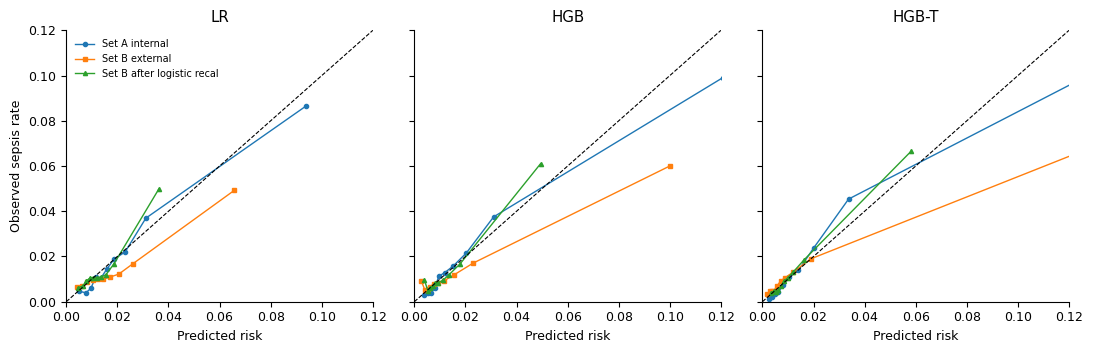

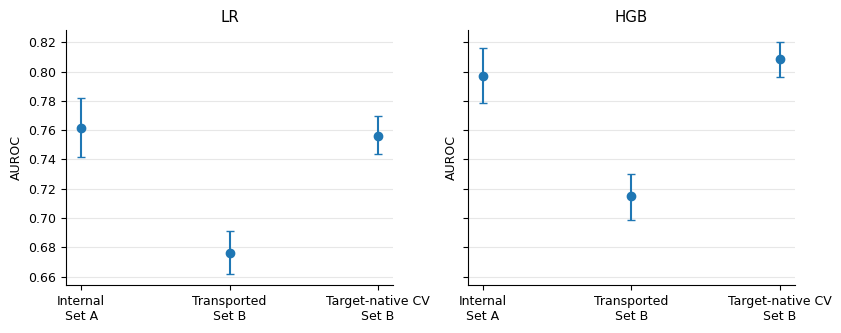

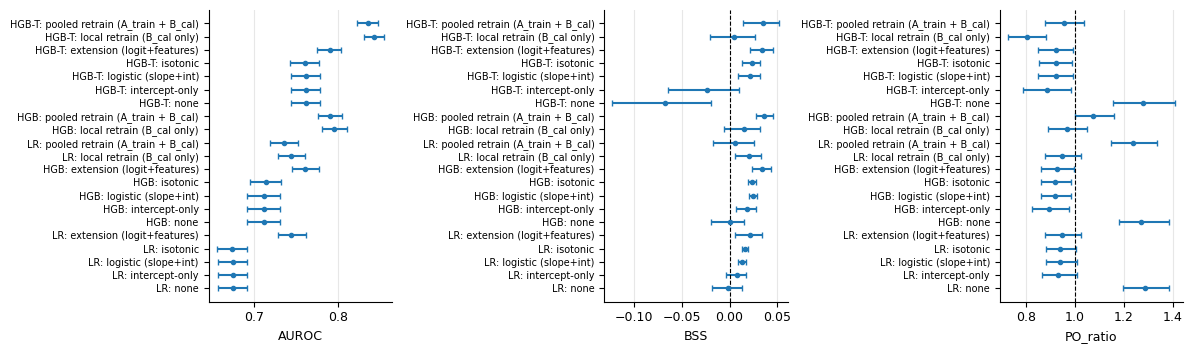

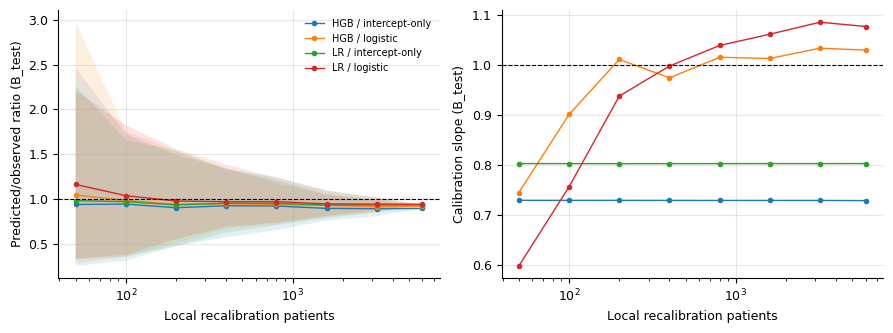

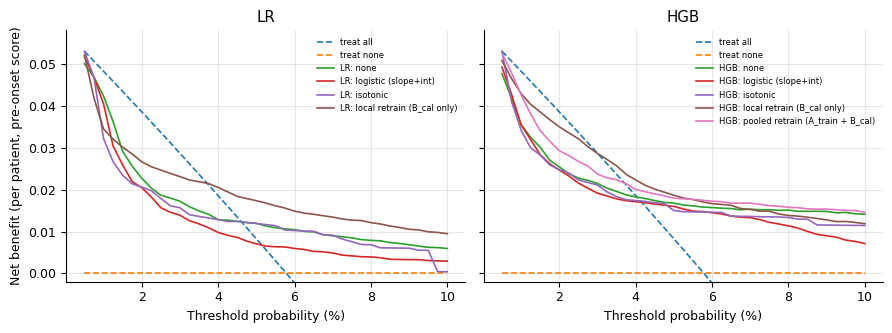

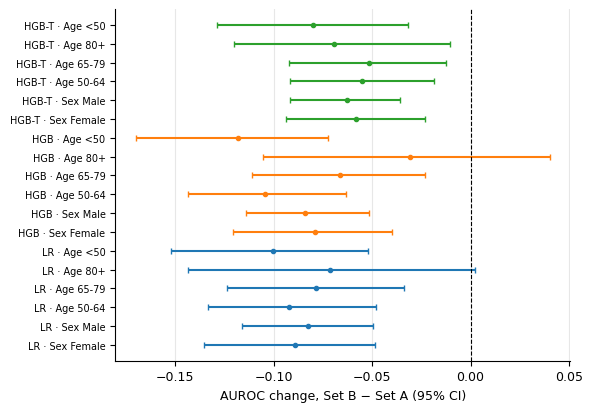

Şekiller kaydedildi: ['fig1_calibration.png', 'fig2_recoverability.png', 'fig3_adaptation_hierarchy.png', 'fig4_recalibration_sample_size.png', 'fig5_decision_curves.png', 'fig6_subgroup_forest.png']


In [20]:
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
from sklearn.calibration import calibration_curve

# Fig 1 — kalibrasyon: 3 model × (A, B, B recal)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, (name, m) in zip(axes, MODELS.items()):
    fam = ADAPT if name != "HGB-T" else ADAPT_T; yt = y_test if name != "HGB-T" else yT_test
    for lab, yy, pp, st in [("Set A internal", m["yA"], m["pA"], "o-"), ("Set B external", m["yB"], m["pB"], "s-"),
                            ("Set B after logistic recal", yt, fam[f"{name}: logistic (slope+int)"], "^-")]:
        f, mp = calibration_curve(yy, pp, n_bins=10, strategy="quantile"); ax.plot(mp, f, st, ms=3, lw=1, label=lab)
    ax.plot([0, .12], [0, .12], "k--", lw=.8); ax.set_xlim(0, .12); ax.set_ylim(0, .12); ax.set_title(name); ax.set_xlabel("Predicted risk")
axes[0].set_ylabel("Observed sepsis rate"); axes[0].legend(fontsize=7, frameon=False); fig.tight_layout()
fig.savefig(OUT / "fig1_calibration.png", dpi=300); FIGS["fig1"] = fig

# Fig 2 — transport loss and target-native recoverability
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4), sharey=True)
for ax, mdl in zip(axes, ["LR", "HGB"]):
    d = RECOVER_CI[[f"{mdl} point", f"{mdl} lo", f"{mdl} hi"]].loc[["internal_AUROC", "transported_AUROC", "target_native_CV_AUROC"]]
    x = np.arange(3)
    ax.errorbar(x, d.iloc[:,0], yerr=[d.iloc[:,0]-d.iloc[:,1], d.iloc[:,2]-d.iloc[:,0]], fmt="o", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(["Internal\nSet A", "Transported\nSet B", "Target-native CV\nSet B"])
    ax.set_title(mdl)
    ax.set_ylabel("AUROC")
    ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "fig2_recoverability.png", dpi=300); FIGS["fig2"] = fig

# Fig 3 — adaptasyon hiyerarşisi: AUROC vs BSS, PO ratio
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, met in zip(axes, ["AUROC", "BSS", "PO_ratio"]):
    sub = R[R.index.str.endswith(" | " + met)]; labels = [i.split(" | ")[0] for i in sub.index]
    ax.errorbar(sub.point, range(len(sub)), xerr=[sub.point - sub.lo, sub.hi - sub.point], fmt="o", capsize=2, ms=3)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(labels, fontsize=7); ax.set_xlabel(met); ax.grid(axis="x", alpha=.3)
    if met == "PO_ratio": ax.axvline(1, color="k", lw=.8, ls="--")
    if met == "BSS": ax.axvline(0, color="k", lw=.8, ls="--")
fig.tight_layout(); fig.savefig(OUT / "fig3_adaptation_hierarchy.png", dpi=300); FIGS["fig3"] = fig

# Fig 4 — örneklem eğrisi
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, met in zip(axes, ["ratio", "slope"]):
    for (mdl, meth), g in LCs.groupby(["model", "method"]):
        ax.plot(g.n_patients, g[f"{met}_med"], "o-", ms=3, lw=1, label=f"{mdl} / {meth}")
        if met == "ratio": ax.fill_between(g.n_patients, g.ratio_p5, g.ratio_p95, alpha=.12)
    ax.set_xscale("log"); ax.axhline(1, color="k", ls="--", lw=.8); ax.set_xlabel("Local recalibration patients"); ax.set_ylabel({"ratio": "Predicted/observed ratio (B_test)", "slope": "Calibration slope (B_test)"}[met]); ax.grid(alpha=.3)
axes[0].legend(fontsize=7, frameon=False); fig.tight_layout(); fig.savefig(OUT / "fig4_recalibration_sample_size.png", dpi=300); FIGS["fig4"] = fig

# Fig 5 — decision curves
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, D, ttl in zip(axes, [DCA_LR, DCA_HGB], ["LR", "HGB"]):
    for c in D.columns[1:]: ax.plot(D.threshold * 100, D[c], lw=1.2, label=c, ls="--" if c.startswith("treat") else "-")
    ax.set_xlabel("Threshold probability (%)"); ax.set_title(ttl); ax.set_ylim(-0.002, None); ax.grid(alpha=.3); ax.legend(fontsize=6, frameon=False)
axes[0].set_ylabel("Net benefit (per patient, pre-onset score)"); fig.tight_layout(); fig.savefig(OUT / "fig5_decision_curves.png", dpi=300); FIGS["fig5"] = fig

# Fig 6 — alt grup forest: AUROC kaybı (B−A) GA'lı
fig, ax = plt.subplots(figsize=(6, 4.2)); sub = TABLES["table7_subgroups"]; yv = 0; ticks = []
for mdl, g in sub.groupby("model", sort=False):
    for _, r in g.iterrows():
        ax.errorbar(r.dAUROC, yv, xerr=[[r.dAUROC - r.dAUROC_lo], [r.dAUROC_hi - r.dAUROC]], fmt="o", ms=3, capsize=2, color={"LR": "C0", "HGB": "C1", "HGB-T": "C2"}[mdl])
        ticks.append(f"{mdl} · {r.variable} {r.level}"); yv += 1
ax.set_yticks(range(yv)); ax.set_yticklabels(ticks, fontsize=7); ax.axvline(0, color="k", lw=.8, ls="--"); ax.set_xlabel("AUROC change, Set B − Set A (95% CI)"); ax.grid(axis="x", alpha=.3)
fig.tight_layout(); fig.savefig(OUT / "fig6_subgroup_forest.png", dpi=300); FIGS["fig6"] = fig
plt.show(); print("Şekiller kaydedildi:", sorted(p.name for p in OUT.glob("*.png")))


In [21]:
import sklearn, sys
with pd.ExcelWriter(OUT / "q1_tables_FINAL.xlsx") as xw:
    for k, v in TABLES.items():
        (v if isinstance(v, pd.DataFrame) else v.to_frame()).to_excel(xw, sheet_name=k[:31])
for k, v in TABLES.items():
    (v if isinstance(v, pd.DataFrame) else v.to_frame()).to_csv(OUT / f"{k}.csv")
json.dump({"python": sys.version, "sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__,
           "analysis_version": "Q1_FINAL_no_reweighting", "FAST_MODE": FAST_MODE, "N_BOOT": N_BOOT, "N_BOOT_SG": N_BOOT_SG, "REPS_LC": REPS_LC, "SEED": SEED, "split_seed": 42, "recal_split": "30/70 patient-level, seed 42",
           "temporal_features": temporal_features}, open(OUT / "environment.json", "w"), indent=2)
print("Tamam →", OUT.resolve())


Tamam → /home/omer/q1_outputs_v2


In [22]:
# ============================================================
# HGB-T TARGET-NATIVE CV + RECOVERABILITY
# ============================================================

import time
import joblib

# ---- 1. Gerekli nesneleri kontrol et ----
needed = [
    "A_T_val", "B_T", "temporal_features",
    "pT_A", "pT_B",
    "hgb_safe", "PatientBoot",
    "roc_auc_score", "N_BOOT", "OUT"
]

missing = [x for x in needed if x not in globals()]

if missing:
    raise NameError(f"Eksik değişken/fonksiyonlar: {missing}")

print("Tüm gerekli değişkenler hazır ✅")

# ---- 2. Dizileri hazırla ----
yA_T   = A_T_val["SepsisLabel"].to_numpy()
pidA_T = A_T_val["patient_id"].to_numpy()

yB_T   = B_T["SepsisLabel"].to_numpy()
pidB_T = B_T["patient_id"].to_numpy()

print("A_T_val hasta:", len(np.unique(pidA_T)))
print("B_T hasta:", len(np.unique(pidB_T)))
print("Temporal özellik:", len(temporal_features))

# ---- 3. B üzerinde target-native 5-fold patient-grouped CV ----
t0 = time.time()

pB_native_hgbT = cross_val_predict(
    hgb_safe(),
    B_T[temporal_features],
    yB_T,
    groups=pidB_T,
    cv=GroupKFold(5),
    method="predict_proba",
    n_jobs=1
)[:, 1]

print(
    f"HGB-T target-native 5-fold CV tamam: "
    f"{(time.time()-t0)/60:.1f} dakika"
)

print(
    "HGB-T target-native CV AUROC:",
    round(roc_auc_score(yB_T, pB_native_hgbT), 4)
)

# ---- 4. HGB-T recoverability bootstrap ----
def recoverability_ci_generic(
    name,
    yA, pA, pidA,
    yB, pB, pnative, pidB,
    n_boot=1000,
    seed=73
):
    yA = np.asarray(yA)
    pA = np.asarray(pA)
    pidA = np.asarray(pidA)

    yB = np.asarray(yB)
    pB = np.asarray(pB)
    pnative = np.asarray(pnative)
    pidB = np.asarray(pidB)

    bA = PatientBoot(pidA)
    bB = PatientBoot(pidB)

    rng = np.random.default_rng(seed)

    def calc(ia, ib):
        internal = roc_auc_score(yA[ia], pA[ia])
        transported = roc_auc_score(yB[ib], pB[ib])
        native = roc_auc_score(yB[ib], pnative[ib])

        return {
            "internal_AUROC": internal,
            "transported_AUROC": transported,
            "target_native_CV_AUROC": native,
            "transport_loss_B_minus_A": transported - internal,
            "recoverable_by_target_retraining": native - transported,
        }

    # Nokta tahminleri
    point = calc(
        np.arange(len(yA)),
        np.arange(len(yB))
    )

    rows = []
    t0 = time.time()

    for i in range(n_boot):
        try:
            rows.append(
                calc(
                    bA.sample(rng),
                    bB.sample(rng)
                )
            )
        except ValueError:
            pass

        if (i + 1) % 100 == 0:
            print(
                f"Bootstrap {i+1}/{n_boot} tamam "
                f"({(time.time()-t0)/60:.1f} dk)"
            )

    raw = pd.DataFrame(rows)

    summary = pd.DataFrame({
        f"{name} point": pd.Series(point),
        f"{name} lo": raw.quantile(0.025),
        f"{name} hi": raw.quantile(0.975)
    })

    return summary, raw


HGBT_RECOVER_CI, HGBT_RECOVER_RAW = recoverability_ci_generic(
    name="HGB-T",
    yA=yA_T,
    pA=pT_A,
    pidA=pidA_T,
    yB=yB_T,
    pB=pT_B,
    pnative=pB_native_hgbT,
    pidB=pidB_T,
    n_boot=N_BOOT,
    seed=73
)

print("\n=== HGB-T RECOVERABILITY ===")
display(HGBT_RECOVER_CI.round(4))

# ---- 5. Yayın için özet satır ----
HGBT_FINAL = pd.DataFrame({
    "Model": ["HGB-T"],
    "Internal AUROC": [
        roc_auc_score(yA_T, pT_A)
    ],
    "Transported AUROC": [
        roc_auc_score(yB_T, pT_B)
    ],
    "Target-native CV AUROC": [
        roc_auc_score(yB_T, pB_native_hgbT)
    ],
})

HGBT_FINAL["Transport loss"] = (
    HGBT_FINAL["Transported AUROC"]
    - HGBT_FINAL["Internal AUROC"]
)

HGBT_FINAL["Recoverable by target retraining"] = (
    HGBT_FINAL["Target-native CV AUROC"]
    - HGBT_FINAL["Transported AUROC"]
)

print("\n=== HGB-T FINAL ROW ===")
display(HGBT_FINAL.round(4))

# ---- 6. Ham bootstrapları ve özetleri diske kaydet ----
HGBT_RECOVER_RAW.to_csv(
    OUT / "hgbt_recoverability_bootstrap_raw.csv",
    index=False
)

HGBT_RECOVER_CI.to_csv(
    OUT / "hgbt_recoverability_CI.csv"
)

HGBT_FINAL.to_csv(
    OUT / "hgbt_recoverability_final.csv",
    index=False
)

joblib.dump(
    {
        "pB_native_hgbT": pB_native_hgbT,
        "bootstrap_raw": HGBT_RECOVER_RAW,
        "summary": HGBT_RECOVER_CI,
        "final": HGBT_FINAL,
        "N_BOOT": N_BOOT,
        "seed": 73
    },
    OUT / "hgbt_recoverability_full.joblib"
)

print("\nKaydedildi ✅")
print(OUT.resolve())

Tüm gerekli değişkenler hazır ✅
A_T_val hasta: 4068
B_T hasta: 20000
Temporal özellik: 133
HGB-T target-native 5-fold CV tamam: 0.4 dakika
HGB-T target-native CV AUROC: 0.8587
Bootstrap 100/1000 tamam (0.5 dk)
Bootstrap 200/1000 tamam (0.9 dk)
Bootstrap 300/1000 tamam (1.4 dk)
Bootstrap 400/1000 tamam (1.9 dk)
Bootstrap 500/1000 tamam (2.3 dk)
Bootstrap 600/1000 tamam (2.8 dk)
Bootstrap 700/1000 tamam (3.2 dk)
Bootstrap 800/1000 tamam (3.7 dk)
Bootstrap 900/1000 tamam (4.1 dk)
Bootstrap 1000/1000 tamam (4.6 dk)

=== HGB-T RECOVERABILITY ===


,HGB-T point,HGB-T lo,HGB-T hi
internal_AUROC,0.8266,0.8082,0.8444
transported_AUROC,0.7662,0.7536,0.7778
target_native_CV_AUROC,0.8587,0.8499,0.8680
transport_loss_B_minus_A,-0.0605,-0.0818,-0.0377
recoverable_by_target_retraining,0.0925,0.0814,0.1038



=== HGB-T FINAL ROW ===


,Model,Internal AUROC,Transported AUROC,Target-native CV AUROC,Transport loss,Recoverable by target retraining
0,HGB-T,0.8266,0.7662,0.8587,-0.0605,0.0925



Kaydedildi ✅
/home/omer/q1_outputs_v2


=== FINAL TABLE 3 ===


,Model,Internal AUROC,Transported AUROC,Target-native CV AUROC,Transport loss,Recoverable by target retraining
0,LR,0.7618,0.6762,0.7560,-0.0856,0.0798
1,HGB,0.7972,0.7150,0.8084,-0.0821,0.0934
2,HGB-T,0.8266,0.7662,0.8587,-0.0605,0.0925



=== FINAL RECOVERABILITY CI ===


,LR point,LR lo,LR hi,HGB point,HGB lo,HGB hi,HGB-T point,HGB-T lo,HGB-T hi
internal_AUROC,0.7618,0.7418,0.7821,0.7972,0.7785,0.8160,0.8266,0.8082,0.8444
transported_AUROC,0.6762,0.6620,0.6912,0.7150,0.6988,0.7303,0.7662,0.7536,0.7778
target_native_CV_AUROC,0.7560,0.7435,0.7695,0.8084,0.7963,0.8203,0.8587,0.8499,0.8680
transport_loss_B_minus_A,-0.0856,-0.1107,-0.0606,-0.0821,-0.1065,-0.0578,-0.0605,-0.0818,-0.0377
recoverable_by_target_retraining,0.0798,0.0680,0.0925,0.0934,0.0788,0.1093,0.0925,0.0814,0.1038


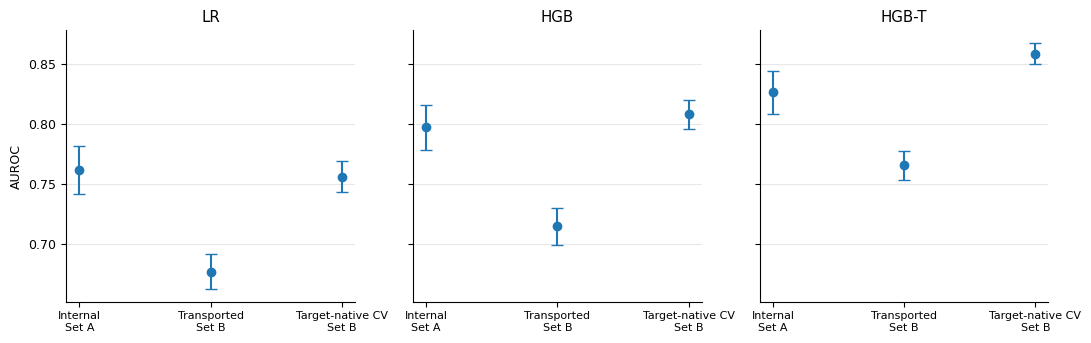


Final Table 3 ve Figure 2 kaydedildi ✅
/home/omer/q1_outputs_v2


In [23]:
# ============================================================
# FINALIZE HGB-T RECOVERABILITY + FIGURE 2
# ============================================================

# Table 3: LR + HGB + HGB-T
RECOVER_CI_FULL = pd.concat(
    [RECOVER_CI, HGBT_RECOVER_CI],
    axis=1
)

FINAL_T3_FULL = pd.concat(
    [FINAL_T3, HGBT_FINAL],
    ignore_index=True
)

TABLES["table3_recoverability_CI"] = RECOVER_CI_FULL
TABLES["table3_final_recoverability"] = FINAL_T3_FULL

print("=== FINAL TABLE 3 ===")
display(FINAL_T3_FULL.round(4))

print("\n=== FINAL RECOVERABILITY CI ===")
display(RECOVER_CI_FULL.round(4))


# ------------------------------------------------------------
# Figure 2 — üç model
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(11, 3.5),
    sharey=True
)

for ax, mdl in zip(
    axes,
    ["LR", "HGB", "HGB-T"]
):

    d = RECOVER_CI_FULL[
        [f"{mdl} point", f"{mdl} lo", f"{mdl} hi"]
    ].loc[
        [
            "internal_AUROC",
            "transported_AUROC",
            "target_native_CV_AUROC"
        ]
    ]

    x = np.arange(3)

    ax.errorbar(
        x,
        d.iloc[:, 0],
        yerr=[
            d.iloc[:, 0] - d.iloc[:, 1],
            d.iloc[:, 2] - d.iloc[:, 0]
        ],
        fmt="o",
        capsize=4
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Internal\nSet A",
            "Transported\nSet B",
            "Target-native CV\nSet B"
        ],
        fontsize=8
    )

    ax.set_title(mdl)
    ax.grid(axis="y", alpha=.3)

axes[0].set_ylabel("AUROC")

fig.tight_layout()

fig.savefig(
    OUT / "fig2_recoverability_FINAL_3models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Ek güvenli CSV kopyaları
FINAL_T3_FULL.to_csv(
    OUT / "table3_final_recoverability_HGBT.csv",
    index=False
)

RECOVER_CI_FULL.to_csv(
    OUT / "table3_recoverability_CI_HGBT.csv"
)

print("\nFinal Table 3 ve Figure 2 kaydedildi ✅")
print(OUT.resolve())

In [24]:
# ============================================================
# REPEATED-SPLIT ROBUSTNESS ANALYSIS
# 5 patient-level B_cal/B_test splits
# Amaç: ana adaptasyon sonuçları tek seed'e bağlı mı?
# Bootstrap YOK.
# ============================================================

import gc
import time
from pathlib import Path

ROBUST_SEEDS = [11, 23, 42, 73, 101]

# Utility çok daha yavaş olabilir.
# İlk çalıştırmada False bırak.
RUN_UTILITY = False


# ============================================================
# 0. GEREKLİ DEĞİŞKENLERİ KONTROL ET
# ============================================================

required = [
    "np", "pd",
    "B_data", "B_T",
    "A_train", "A_T_train",
    "features", "hgb_features", "temporal_features",
    "model", "hgb_model", "hgbT",
    "lr_pipeline", "hgb_safe",
    "logit", "cal_slope", "cal_intercept_citl", "ece",
    "roc_auc_score", "brier_score_loss", "net_benefit",
    "GroupShuffleSplit", "LogisticRegression",
    "OUT", "TABLES"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise NameError(
        f"Önce şu değişken/fonksiyonlar oluşturulmalı: {missing}"
    )

OUT = Path(OUT)
OUT.mkdir(exist_ok=True)

print("Tüm gerekli nesneler hazır ✅")


# ============================================================
# 1. METRİKLER
# ============================================================

def robust_metrics(y, p):

    y = np.asarray(y).astype(int)
    p = np.asarray(p, float)

    prev = y.mean()

    br = brier_score_loss(y, p)
    null = prev * (1 - prev)

    out = {
        "AUROC": roc_auc_score(y, p),

        "BSS":
            1 - br / null
            if null > 0
            else np.nan,

        "PO_ratio":
            p.mean() / prev
            if prev > 0
            else np.nan,

        "ECE": ece(y, p),

        "NB_2pct":
            net_benefit(y, p, 0.02)
    }

    try:
        out["Slope"] = cal_slope(y, p)
    except Exception:
        out["Slope"] = np.nan

    try:
        out["CITL"] = cal_intercept_citl(y, p)
    except Exception:
        out["CITL"] = np.nan

    return out


def logistic_recalibrate(
    p_cal,
    y_cal,
    p_test
):

    lr = LogisticRegression(
        C=1e6,
        max_iter=1000
    )

    lr.fit(
        logit(p_cal).reshape(-1, 1),
        y_cal
    )

    return lr.predict_proba(
        logit(p_test).reshape(-1, 1)
    )[:, 1]


def add_result(
    rows,
    seed,
    model_name,
    method,
    y_test,
    p_test,
    n_cal_pts,
    n_test_pts,
    n_cal_events,
    n_test_events
):

    m = robust_metrics(
        y_test,
        p_test
    )

    rows.append({
        "seed": seed,
        "model": model_name,
        "method": method,

        "n_cal_patients":
            n_cal_pts,

        "n_test_patients":
            n_test_pts,

        "n_cal_sepsis_patients":
            n_cal_events,

        "n_test_sepsis_patients":
            n_test_events,

        **m
    })


# ============================================================
# 2. ANA LOOP
# ============================================================

rows = []

t_all = time.time()

for si, seed in enumerate(
    ROBUST_SEEDS,
    1
):

    t_seed = time.time()

    print(
        "\n"
        + "=" * 60
    )

    print(
        f"SPLIT {si}/{len(ROBUST_SEEDS)}"
        f" | seed={seed}"
    )

    # --------------------------------------------------------
    # Aynı ana tasarım:
    # %30 B_cal / %70 B_test
    # Hasta düzeyinde ayrım
    # --------------------------------------------------------

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.70,
        random_state=seed
    )

    cal_idx_s, test_idx_s = next(
        splitter.split(
            B_data,
            groups=B_data["patient_id"]
        )
    )

    Bcal = B_data.iloc[
        cal_idx_s
    ].copy()

    Btest = B_data.iloc[
        test_idx_s
    ].copy()


    cal_pids = set(
        Bcal["patient_id"].unique()
    )

    test_pids = set(
        Btest["patient_id"].unique()
    )


    # --------------------------------------------------------
    # Temporal HGB-T için aynı hastaları seç
    # --------------------------------------------------------

    BTcal = B_T[
        B_T["patient_id"].isin(
            cal_pids
        )
    ].copy()

    BTtest = B_T[
        B_T["patient_id"].isin(
            test_pids
        )
    ].copy()


    ycal = Bcal[
        "SepsisLabel"
    ].to_numpy()

    ytest = Btest[
        "SepsisLabel"
    ].to_numpy()

    yTcal = BTcal[
        "SepsisLabel"
    ].to_numpy()

    yTtest = BTtest[
        "SepsisLabel"
    ].to_numpy()


    n_cal_pts = (
        Bcal["patient_id"]
        .nunique()
    )

    n_test_pts = (
        Btest["patient_id"]
        .nunique()
    )

    n_cal_events = int(
        Bcal.groupby(
            "patient_id"
        )["SepsisLabel"]
        .max()
        .sum()
    )

    n_test_events = int(
        Btest.groupby(
            "patient_id"
        )["SepsisLabel"]
        .max()
        .sum()
    )


    print(
        f"B_cal: {n_cal_pts} hasta "
        f"| {n_cal_events} sepsis"
    )

    print(
        f"B_test: {n_test_pts} hasta "
        f"| {n_test_events} sepsis"
    )


    # ========================================================
    # LR
    # ========================================================

    print("  LR çalışıyor...")

    pcal_lr = model.predict_proba(
        Bcal[features]
    )[:, 1]

    ptest_lr = model.predict_proba(
        Btest[features]
    )[:, 1]


    P_lr = {}

    P_lr["none"] = ptest_lr


    P_lr[
        "logistic_recalibration"
    ] = logistic_recalibrate(
        pcal_lr,
        ycal,
        ptest_lr
    )


    lr_local = (
        lr_pipeline()
        .fit(
            Bcal[features],
            ycal
        )
    )

    P_lr[
        "local_retrain"
    ] = lr_local.predict_proba(
        Btest[features]
    )[:, 1]


    lr_pool = (
        lr_pipeline()
        .fit(
            pd.concat(
                [
                    A_train[features],
                    Bcal[features]
                ],
                ignore_index=True
            ),

            np.r_[
                A_train[
                    "SepsisLabel"
                ].to_numpy(),

                ycal
            ]
        )
    )

    P_lr[
        "pooled_retrain"
    ] = lr_pool.predict_proba(
        Btest[features]
    )[:, 1]


    for meth, pp in P_lr.items():

        add_result(
            rows,
            seed,
            "LR",
            meth,
            ytest,
            pp,
            n_cal_pts,
            n_test_pts,
            n_cal_events,
            n_test_events
        )


    # ========================================================
    # HGB
    # ========================================================

    print("  HGB çalışıyor...")

    pcal_h = (
        hgb_model
        .predict_proba(
            Bcal[
                hgb_features
            ]
        )[:, 1]
    )

    ptest_h = (
        hgb_model
        .predict_proba(
            Btest[
                hgb_features
            ]
        )[:, 1]
    )


    P_h = {}

    P_h["none"] = ptest_h


    P_h[
        "logistic_recalibration"
    ] = logistic_recalibrate(
        pcal_h,
        ycal,
        ptest_h
    )


    h_local = (
        hgb_safe()
        .fit(
            Bcal[
                hgb_features
            ],
            ycal
        )
    )

    P_h[
        "local_retrain"
    ] = h_local.predict_proba(
        Btest[
            hgb_features
        ]
    )[:, 1]


    h_pool = (
        hgb_safe()
        .fit(
            pd.concat(
                [
                    A_train[
                        hgb_features
                    ],

                    Bcal[
                        hgb_features
                    ]
                ],
                ignore_index=True
            ),

            np.r_[
                A_train[
                    "SepsisLabel"
                ].to_numpy(),

                ycal
            ]
        )
    )

    P_h[
        "pooled_retrain"
    ] = h_pool.predict_proba(
        Btest[
            hgb_features
        ]
    )[:, 1]


    for meth, pp in P_h.items():

        add_result(
            rows,
            seed,
            "HGB",
            meth,
            ytest,
            pp,
            n_cal_pts,
            n_test_pts,
            n_cal_events,
            n_test_events
        )


    # ========================================================
    # HGB-T
    # ========================================================

    print("  HGB-T çalışıyor...")

    pcal_t = (
        hgbT
        .predict_proba(
            BTcal[
                temporal_features
            ]
        )[:, 1]
    )

    ptest_t = (
        hgbT
        .predict_proba(
            BTtest[
                temporal_features
            ]
        )[:, 1]
    )


    P_t = {}

    P_t["none"] = ptest_t


    P_t[
        "logistic_recalibration"
    ] = logistic_recalibrate(
        pcal_t,
        yTcal,
        ptest_t
    )


    ht_local = (
        hgb_safe()
        .fit(
            BTcal[
                temporal_features
            ],
            yTcal
        )
    )

    P_t[
        "local_retrain"
    ] = ht_local.predict_proba(
        BTtest[
            temporal_features
        ]
    )[:, 1]


    ht_pool = (
        hgb_safe()
        .fit(
            pd.concat(
                [
                    A_T_train[
                        temporal_features
                    ],

                    BTcal[
                        temporal_features
                    ]
                ],
                ignore_index=True
            ),

            np.r_[
                A_T_train[
                    "SepsisLabel"
                ].to_numpy(),

                yTcal
            ]
        )
    )

    P_t[
        "pooled_retrain"
    ] = ht_pool.predict_proba(
        BTtest[
            temporal_features
        ]
    )[:, 1]


    for meth, pp in P_t.items():

        add_result(
            rows,
            seed,
            "HGB-T",
            meth,
            yTtest,
            pp,
            n_cal_pts,
            n_test_pts,
            n_cal_events,
            n_test_events
        )


    # ========================================================
    # HER SEED SONRASI CHECKPOINT
    # ========================================================

    ROBUST_RAW = pd.DataFrame(
        rows
    )

    ROBUST_RAW.to_csv(
        OUT /
        "repeated_split_robustness_raw_CHECKPOINT.csv",
        index=False
    )


    print(
        f"seed={seed} tamam ✅ "
        f"| süre="
        f"{(time.time()-t_seed)/60:.1f} dk"
    )


    # Belleği boşalt
    del Bcal, Btest
    del BTcal, BTtest

    del lr_local, lr_pool
    del h_local, h_pool
    del ht_local, ht_pool

    gc.collect()


# ============================================================
# 3. RAW SONUÇLAR
# ============================================================

ROBUST_RAW = pd.DataFrame(
    rows
)

print(
    "\nTüm splitler tamam ✅"
)

display(
    ROBUST_RAW.round(4)
)


# ============================================================
# 4. ÖZET:
# MEDIAN + IQR + MIN/MAX
# ============================================================

metric_cols = [
    "AUROC",
    "BSS",
    "PO_ratio",
    "Slope",
    "CITL",
    "ECE",
    "NB_2pct"
]

summary_rows = []


for (
    mdl,
    meth
), g in ROBUST_RAW.groupby(
    [
        "model",
        "method"
    ],
    sort=False
):

    row = {
        "model": mdl,
        "method": meth,
        "n_splits":
            g["seed"].nunique()
    }


    for col in metric_cols:

        s = g[
            col
        ].dropna()

        row[
            f"{col}_median"
        ] = s.median()

        row[
            f"{col}_q1"
        ] = s.quantile(
            0.25
        )

        row[
            f"{col}_q3"
        ] = s.quantile(
            0.75
        )

        row[
            f"{col}_min"
        ] = s.min()

        row[
            f"{col}_max"
        ] = s.max()


    summary_rows.append(
        row
    )


ROBUST_SUMMARY = pd.DataFrame(
    summary_rows
)


# ============================================================
# 5. HER SPLIT'TE "NONE" İLE KARŞILAŞTIR
# ============================================================

gain_rows = []


for (
    seed,
    mdl
), g in ROBUST_RAW.groupby(
    [
        "seed",
        "model"
    ]
):


    base = (
        g.loc[
            g["method"] ==
            "none"
        ]
        .iloc[0]
    )


    for meth in [
        "logistic_recalibration",
        "local_retrain",
        "pooled_retrain"
    ]:


        r = (
            g.loc[
                g["method"] ==
                meth
            ]
            .iloc[0]
        )


        gain_rows.append({

            "seed":
                seed,

            "model":
                mdl,

            "method":
                meth,


            # Pozitif = AUROC iyileşti
            "delta_AUROC_vs_none":
                r["AUROC"]
                -
                base["AUROC"],


            # Pozitif = BSS iyileşti
            "delta_BSS_vs_none":
                r["BSS"]
                -
                base["BSS"],


            # Negatif = PO ratio ideal 1'e yaklaştı
            "delta_abs_PO_error_vs_none":
                abs(
                    r["PO_ratio"]
                    - 1
                )
                -
                abs(
                    base[
                        "PO_ratio"
                    ]
                    - 1
                ),


            # Negatif = slope ideal 1'e yaklaştı
            "delta_abs_slope_error_vs_none":
                abs(
                    r["Slope"]
                    - 1
                )
                -
                abs(
                    base[
                        "Slope"
                    ]
                    - 1
                ),


            # Pozitif = net benefit iyileşti
            "delta_NB_2pct_vs_none":
                r["NB_2pct"]
                -
                base["NB_2pct"]

        })


ROBUST_GAINS = pd.DataFrame(
    gain_rows
)


# ============================================================
# 6. GAIN SUMMARY
# ============================================================

gain_summary_rows = []


gain_metrics = [
    "delta_AUROC_vs_none",
    "delta_BSS_vs_none",
    "delta_abs_PO_error_vs_none",
    "delta_abs_slope_error_vs_none",
    "delta_NB_2pct_vs_none"
]


for (
    mdl,
    meth
), g in ROBUST_GAINS.groupby(
    [
        "model",
        "method"
    ],
    sort=False
):


    row = {

        "model":
            mdl,

        "method":
            meth,

        "n_splits":
            g["seed"].nunique(),

        "AUROC_improved_in_n_splits":

            int(
                (
                    g[
                        "delta_AUROC_vs_none"
                    ]
                    > 0
                ).sum()
            )
    }


    for col in gain_metrics:

        s = g[
            col
        ].dropna()

        row[
            f"{col}_median"
        ] = s.median()

        row[
            f"{col}_min"
        ] = s.min()

        row[
            f"{col}_max"
        ] = s.max()


    gain_summary_rows.append(
        row
    )


ROBUST_GAIN_SUMMARY = pd.DataFrame(
    gain_summary_rows
)


# ============================================================
# 7. KAYDET
# ============================================================

ROBUST_RAW.to_csv(
    OUT /
    "repeated_split_robustness_raw.csv",
    index=False
)

ROBUST_SUMMARY.to_csv(
    OUT /
    "repeated_split_robustness_summary.csv",
    index=False
)

ROBUST_GAINS.to_csv(
    OUT /
    "repeated_split_robustness_gains.csv",
    index=False
)

ROBUST_GAIN_SUMMARY.to_csv(
    OUT /
    "repeated_split_robustness_gain_summary.csv",
    index=False
)


# Ayrı Excel dosyası:
# eski q1_tables_FINAL.xlsx'e dokunmaz.

with pd.ExcelWriter(
    OUT /
    "repeated_split_robustness.xlsx"
) as xw:

    ROBUST_RAW.to_excel(
        xw,
        sheet_name=
        "raw_5_splits",
        index=False
    )

    ROBUST_SUMMARY.to_excel(
        xw,
        sheet_name=
        "summary",
        index=False
    )

    ROBUST_GAINS.to_excel(
        xw,
        sheet_name=
        "within_seed_gains",
        index=False
    )

    ROBUST_GAIN_SUMMARY.to_excel(
        xw,
        sheet_name=
        "gain_summary",
        index=False
    )


# Notebook belleğinde de tut
TABLES[
    "supp_repeated_split_raw"
] = ROBUST_RAW

TABLES[
    "supp_repeated_split_summary"
] = ROBUST_SUMMARY

TABLES[
    "supp_repeated_split_gains"
] = ROBUST_GAINS

TABLES[
    "supp_repeated_split_gain_summary"
] = ROBUST_GAIN_SUMMARY


# ============================================================
# 8. EKRANDA GÖSTER
# ============================================================

print(
    "\n"
    "=== REPEATED-SPLIT ROBUSTNESS SUMMARY ==="
)

display(

    ROBUST_SUMMARY[
        [
            "model",
            "method",

            "AUROC_median",
            "AUROC_min",
            "AUROC_max",

            "PO_ratio_median",
            "Slope_median",
            "BSS_median"
        ]
    ].round(4)

)


print(
    "\n"
    "=== GAINS VS UNADAPTED MODEL ==="
)

display(

    ROBUST_GAIN_SUMMARY[
        [
            "model",
            "method",

            "AUROC_improved_in_n_splits",

            "delta_AUROC_vs_none_median",
            "delta_AUROC_vs_none_min",
            "delta_AUROC_vs_none_max"
        ]
    ].round(4)

)


print(
    "\nTamam ✅"
)

print(
    f"Toplam süre: "
    f"{(time.time()-t_all)/60:.1f} dakika"
)

print(
    "Dosyalar →",
    OUT.resolve()
)

Tüm gerekli nesneler hazır ✅

SPLIT 1/5 | seed=11
B_cal: 6000 hasta | 365 sepsis
B_test: 14000 hasta | 777 sepsis
  LR çalışıyor...
  HGB çalışıyor...
  HGB-T çalışıyor...
seed=11 tamam ✅ | süre=0.4 dk

SPLIT 2/5 | seed=23
B_cal: 6000 hasta | 351 sepsis
B_test: 14000 hasta | 791 sepsis
  LR çalışıyor...
  HGB çalışıyor...
  HGB-T çalışıyor...
seed=23 tamam ✅ | süre=0.4 dk

SPLIT 3/5 | seed=42
B_cal: 6000 hasta | 332 sepsis
B_test: 14000 hasta | 810 sepsis
  LR çalışıyor...
  HGB çalışıyor...
  HGB-T çalışıyor...
seed=42 tamam ✅ | süre=0.4 dk

SPLIT 4/5 | seed=73
B_cal: 6000 hasta | 346 sepsis
B_test: 14000 hasta | 796 sepsis
  LR çalışıyor...
  HGB çalışıyor...
  HGB-T çalışıyor...
seed=73 tamam ✅ | süre=0.4 dk

SPLIT 5/5 | seed=101
B_cal: 6000 hasta | 363 sepsis
B_test: 14000 hasta | 779 sepsis
  LR çalışıyor...
  HGB çalışıyor...
  HGB-T çalışıyor...
seed=101 tamam ✅ | süre=0.4 dk

Tüm splitler tamam ✅


,seed,model,method,n_cal_patients,n_test_patients,n_cal_sepsis_patients,n_test_sepsis_patients,AUROC,BSS,PO_ratio,ECE,NB_2pct,Slope,CITL
0,11,LR,none,6000,14000,365,777,0.6795,-0.0047,1.3441,0.0053,0.0021,0.7973,-0.3132
1,11,LR,logistic_recalibration,6000,14000,365,777,0.6795,0.0133,1.0866,0.0030,0.0028,1.0460,-0.0855
2,11,LR,local_retrain,6000,14000,365,777,0.7477,0.0287,1.0971,0.0018,0.0044,0.9691,-0.0986
3,11,LR,pooled_retrain,6000,14000,365,777,0.7414,0.0133,1.3181,0.0046,0.0041,0.9482,-0.2948
4,11,HGB,none,6000,14000,365,777,0.7185,-0.0026,1.3377,0.0061,0.0038,0.7413,-0.3174
5,11,HGB,logistic_recalibration,6000,14000,365,777,0.7185,0.0247,1.0750,0.0032,0.0040,1.0896,-0.0747
6,11,HGB,local_retrain,6000,14000,365,777,0.7982,0.0140,1.1483,0.0025,0.0055,0.8292,-0.1545
7,11,HGB,pooled_retrain,6000,14000,365,777,0.7989,0.0254,1.2226,0.0032,0.0051,0.9215,-0.2174
8,11,HGB-T,none,6000,14000,365,777,0.7682,-0.0875,1.3839,0.0070,0.0046,0.6501,-0.3926
9,11,HGB-T,logistic_recalibration,6000,14000,365,777,0.7682,0.0179,1.1175,0.0016,0.0046,0.9728,-0.1180



=== REPEATED-SPLIT ROBUSTNESS SUMMARY ===


,model,method,AUROC_median,AUROC_min,AUROC_max,PO_ratio_median,Slope_median,BSS_median
0,LR,none,0.6780,0.6754,0.6798,1.3424,0.7938,-0.0047
1,LR,logistic_recalibration,0.6780,0.6754,0.6798,1.0689,1.0393,0.0133
2,LR,local_retrain,0.7493,0.7446,0.7555,1.0866,0.8865,0.0207
3,LR,pooled_retrain,0.7408,0.7355,0.7449,1.3181,0.8919,0.0062
4,HGB,none,0.7185,0.7117,0.7208,1.3377,0.7294,-0.0059
5,HGB,logistic_recalibration,0.7185,0.7117,0.7208,1.0745,1.0304,0.0237
6,HGB,local_retrain,0.7956,0.7874,0.7995,1.1469,0.7958,0.0128
7,HGB,pooled_retrain,0.7922,0.7903,0.7989,1.2226,0.9215,0.0254
8,HGB-T,none,0.7639,0.7587,0.7723,1.3839,0.6501,-0.0875
9,HGB-T,logistic_recalibration,0.7639,0.7587,0.7723,1.1175,0.9632,0.0179



=== GAINS VS UNADAPTED MODEL ===


,model,method,AUROC_improved_in_n_splits,delta_AUROC_vs_none_median,delta_AUROC_vs_none_min,delta_AUROC_vs_none_max
0,HGB,logistic_recalibration,0,0.0000,0.0000,0.0000
1,HGB,local_retrain,5,0.0795,0.0681,0.0839
2,HGB,pooled_retrain,5,0.0780,0.0722,0.0804
3,HGB-T,logistic_recalibration,0,0.0000,0.0000,0.0000
4,HGB-T,local_retrain,5,0.0770,0.0665,0.0820
5,HGB-T,pooled_retrain,5,0.0732,0.0725,0.0770
6,LR,logistic_recalibration,3,0.0000,-0.0000,0.0000
7,LR,local_retrain,5,0.0704,0.0682,0.0779
8,LR,pooled_retrain,5,0.0619,0.0598,0.0672



Tamam ✅
Toplam süre: 1.9 dakika
Dosyalar → /home/omer/q1_outputs_v2


In [25]:
# ============================================================
# REVIEWER REVISION 1
# CROSS-FITTED POST-RETRAINING RECALIBRATION
# ============================================================

import gc
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss


# ------------------------------------------------------------
# 0. Kontrol
# ------------------------------------------------------------

needed = [
    "A_train", "A_T_train",
    "B_cal", "B_test", "B_T_cal", "B_T_test",
    "features", "hgb_features", "temporal_features",
    "lr_pipeline", "hgb_safe",
    "p_B", "p_B_hgb", "pT_cal", "pT_test",
    "cal_idx", "test_idx",
    "logit", "metrics", "OUT", "TABLES"
]

missing = [x for x in needed if x not in globals()]

if missing:
    raise NameError(f"Eksik nesneler: {missing}")

print("Gerekli nesneler hazır ✅")


# ------------------------------------------------------------
# 1. Logistic recalibrator
# ------------------------------------------------------------

def fit_recalibrator(y, p):

    y = np.asarray(y).astype(int)
    p = np.asarray(p, float)

    lr = LogisticRegression(
        C=1e6,
        max_iter=1000
    )

    lr.fit(
        logit(p).reshape(-1, 1),
        y
    )

    return lr


def apply_recalibrator(recal, p):

    return recal.predict_proba(
        logit(np.asarray(p, float)).reshape(-1, 1)
    )[:, 1]


# ------------------------------------------------------------
# 2. Source model için cross-fitted recalibration
# ------------------------------------------------------------

def crossfit_score_recalibration(
    p_cal,
    y_cal,
    groups_cal,
    p_test,
    n_splits=5
):

    p_cal = np.asarray(p_cal, float)
    y_cal = np.asarray(y_cal).astype(int)
    groups_cal = np.asarray(groups_cal)
    p_test = np.asarray(p_test, float)

    oof = np.full(len(y_cal), np.nan)

    cv = GroupKFold(n_splits=n_splits)

    for fold, (tr, va) in enumerate(
        cv.split(
            np.zeros(len(y_cal)),
            y_cal,
            groups_cal
        ),
        1
    ):

        recal = fit_recalibrator(
            y_cal[tr],
            p_cal[tr]
        )

        oof[va] = apply_recalibrator(
            recal,
            p_cal[va]
        )

        print(
            f"    score recal fold {fold}/{n_splits}"
        )

    full_recal = fit_recalibrator(
        y_cal,
        p_cal
    )

    p_test_recal = apply_recalibrator(
        full_recal,
        p_test
    )

    return {
        "cal_oof": oof,
        "test": p_test_recal,
        "recalibrator": full_recal
    }


# ------------------------------------------------------------
# 3. Local / pooled retraining:
#    cross-fitted B_cal prediction +
#    post-retraining recalibration
# ------------------------------------------------------------

def crossfit_retrain_and_recalibrate(
    estimator_factory,
    X_cal,
    y_cal,
    groups_cal,
    X_test,
    source_X=None,
    source_y=None,
    n_splits=5,
    label=""
):

    y_cal = np.asarray(y_cal).astype(int)
    groups_cal = np.asarray(groups_cal)

    oof_raw = np.full(
        len(y_cal),
        np.nan
    )

    cv = GroupKFold(
        n_splits=n_splits
    )

    t0 = time.time()

    for fold, (tr, va) in enumerate(
        cv.split(
            X_cal,
            y_cal,
            groups_cal
        ),
        1
    ):

        model_ = estimator_factory()

        if source_X is None:

            X_train_fold = X_cal.iloc[tr]
            y_train_fold = y_cal[tr]

        else:

            X_train_fold = pd.concat(
                [
                    source_X,
                    X_cal.iloc[tr]
                ],
                axis=0,
                ignore_index=True
            )

            y_train_fold = np.r_[
                np.asarray(source_y),
                y_cal[tr]
            ]


        model_.fit(
            X_train_fold,
            y_train_fold
        )

        oof_raw[va] = (
            model_
            .predict_proba(
                X_cal.iloc[va]
            )[:, 1]
        )

        print(
            f"  {label}: fold "
            f"{fold}/{n_splits} tamam"
        )

        del model_
        gc.collect()


    assert np.isfinite(oof_raw).all()


    # --------------------------------------------
    # OOF predictions üzerinde recalibration
    # --------------------------------------------

    recal = fit_recalibrator(
        y_cal,
        oof_raw
    )

    oof_postcal = apply_recalibrator(
        recal,
        oof_raw
    )


    # --------------------------------------------
    # Full B_cal model
    # --------------------------------------------

    full_model = estimator_factory()

    if source_X is None:

        X_full = X_cal
        y_full = y_cal

    else:

        X_full = pd.concat(
            [
                source_X,
                X_cal
            ],
            axis=0,
            ignore_index=True
        )

        y_full = np.r_[
            np.asarray(source_y),
            y_cal
        ]


    full_model.fit(
        X_full,
        y_full
    )


    p_test_raw = (
        full_model
        .predict_proba(
            X_test
        )[:, 1]
    )


    p_test_postcal = (
        apply_recalibrator(
            recal,
            p_test_raw
        )
    )


    print(
        f"  {label} tamam ✅ "
        f"({(time.time()-t0)/60:.1f} dk)"
    )


    return {

        "cal_oof_raw":
            oof_raw,

        "cal_oof_postcal":
            oof_postcal,

        "test_raw":
            p_test_raw,

        "test_postcal":
            p_test_postcal,

        "full_model":
            full_model,

        "recalibrator":
            recal
    }


# ============================================================
# 4. DATA
# ============================================================

y_cal = (
    B_cal["SepsisLabel"]
    .to_numpy()
)

y_test = (
    B_test["SepsisLabel"]
    .to_numpy()
)

pid_cal_new = (
    B_cal["patient_id"]
    .to_numpy()
)

pid_test_new = (
    B_test["patient_id"]
    .to_numpy()
)


yT_cal_new = (
    B_T_cal["SepsisLabel"]
    .to_numpy()
)

yT_test_new = (
    B_T_test["SepsisLabel"]
    .to_numpy()
)

pidT_cal_new = (
    B_T_cal["patient_id"]
    .to_numpy()
)

pidT_test_new = (
    B_T_test["patient_id"]
    .to_numpy()
)


# ============================================================
# 5. SOURCE MODEL RECALIBRATION — OOF
# ============================================================

print("\nSOURCE SCORE RECALIBRATION")


SRC_RECAL_LR = crossfit_score_recalibration(

    p_B[cal_idx],
    y_cal,
    pid_cal_new,
    p_B[test_idx]
)


SRC_RECAL_HGB = crossfit_score_recalibration(

    p_B_hgb[cal_idx],
    y_cal,
    pid_cal_new,
    p_B_hgb[test_idx]
)


SRC_RECAL_HGBT = crossfit_score_recalibration(

    pT_cal,
    yT_cal_new,
    pidT_cal_new,
    pT_test
)


# ============================================================
# 6. LR
# ============================================================

print("\n===== LR =====")


LR_LOCAL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            lr_pipeline,

        X_cal=
            B_cal[features],

        y_cal=
            y_cal,

        groups_cal=
            pid_cal_new,

        X_test=
            B_test[features],

        source_X=None,
        source_y=None,

        label=
            "LR local"
    )
)


LR_POOL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            lr_pipeline,

        X_cal=
            B_cal[features],

        y_cal=
            y_cal,

        groups_cal=
            pid_cal_new,

        X_test=
            B_test[features],

        source_X=
            A_train[features],

        source_y=
            A_train[
                "SepsisLabel"
            ].to_numpy(),

        label=
            "LR pooled"
    )
)


# ============================================================
# 7. HGB
# ============================================================

print("\n===== HGB =====")


HGB_LOCAL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            hgb_safe,

        X_cal=
            B_cal[hgb_features],

        y_cal=
            y_cal,

        groups_cal=
            pid_cal_new,

        X_test=
            B_test[hgb_features],

        source_X=None,
        source_y=None,

        label=
            "HGB local"
    )
)


HGB_POOL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            hgb_safe,

        X_cal=
            B_cal[hgb_features],

        y_cal=
            y_cal,

        groups_cal=
            pid_cal_new,

        X_test=
            B_test[hgb_features],

        source_X=
            A_train[hgb_features],

        source_y=
            A_train[
                "SepsisLabel"
            ].to_numpy(),

        label=
            "HGB pooled"
    )
)


# ============================================================
# 8. HGB-T
# ============================================================

print("\n===== HGB-T =====")


HGBT_LOCAL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            hgb_safe,

        X_cal=
            B_T_cal[
                temporal_features
            ],

        y_cal=
            yT_cal_new,

        groups_cal=
            pidT_cal_new,

        X_test=
            B_T_test[
                temporal_features
            ],

        source_X=None,
        source_y=None,

        label=
            "HGB-T local"
    )
)


HGBT_POOL_CF = (
    crossfit_retrain_and_recalibrate(

        estimator_factory=
            hgb_safe,

        X_cal=
            B_T_cal[
                temporal_features
            ],

        y_cal=
            yT_cal_new,

        groups_cal=
            pidT_cal_new,

        X_test=
            B_T_test[
                temporal_features
            ],

        source_X=
            A_T_train[
                temporal_features
            ],

        source_y=
            A_T_train[
                "SepsisLabel"
            ].to_numpy(),

        label=
            "HGB-T pooled"
    )
)


# ============================================================
# 9. FAIR ADAPTATION TABLE — POINT ESTIMATES
# ============================================================

def metric_row(
    model_name,
    method,
    y,
    p
):

    m = metrics(y, p)

    return {
        "Model": model_name,
        "Method": method,
        "AUROC": m["AUROC"],
        "BSS": m["BSS"],
        "PO_ratio": m["PO_ratio"],
        "Slope": m["Slope"],
        "CITL": m["CITL"],
        "ECE": m["ECE"]
    }


rows = []


# LR
for meth, pp in [

    (
        "Transported",
        p_B[test_idx]
    ),

    (
        "Transported + logistic recalibration",
        SRC_RECAL_LR["test"]
    ),

    (
        "Local retrain",
        LR_LOCAL_CF[
            "test_raw"
        ]
    ),

    (
        "Local retrain + post-retrain recalibration",
        LR_LOCAL_CF[
            "test_postcal"
        ]
    ),

    (
        "Pooled retrain",
        LR_POOL_CF[
            "test_raw"
        ]
    ),

    (
        "Pooled retrain + post-retrain recalibration",
        LR_POOL_CF[
            "test_postcal"
        ]
    )
]:

    rows.append(
        metric_row(
            "LR",
            meth,
            y_test,
            pp
        )
    )


# HGB
for meth, pp in [

    (
        "Transported",
        p_B_hgb[test_idx]
    ),

    (
        "Transported + logistic recalibration",
        SRC_RECAL_HGB["test"]
    ),

    (
        "Local retrain",
        HGB_LOCAL_CF[
            "test_raw"
        ]
    ),

    (
        "Local retrain + post-retrain recalibration",
        HGB_LOCAL_CF[
            "test_postcal"
        ]
    ),

    (
        "Pooled retrain",
        HGB_POOL_CF[
            "test_raw"
        ]
    ),

    (
        "Pooled retrain + post-retrain recalibration",
        HGB_POOL_CF[
            "test_postcal"
        ]
    )
]:

    rows.append(
        metric_row(
            "HGB",
            meth,
            y_test,
            pp
        )
    )


# HGB-T
for meth, pp in [

    (
        "Transported",
        pT_test
    ),

    (
        "Transported + logistic recalibration",
        SRC_RECAL_HGBT["test"]
    ),

    (
        "Local retrain",
        HGBT_LOCAL_CF[
            "test_raw"
        ]
    ),

    (
        "Local retrain + post-retrain recalibration",
        HGBT_LOCAL_CF[
            "test_postcal"
        ]
    ),

    (
        "Pooled retrain",
        HGBT_POOL_CF[
            "test_raw"
        ]
    ),

    (
        "Pooled retrain + post-retrain recalibration",
        HGBT_POOL_CF[
            "test_postcal"
        ]
    )
]:

    rows.append(
        metric_row(
            "HGB-T",
            meth,
            yT_test_new,
            pp
        )
    )


TABLE4_FAIR_POINT = pd.DataFrame(
    rows
)


TABLES[
    "table4_fair_post_recal"
] = TABLE4_FAIR_POINT


print(
    "\n=== FAIR ADAPTATION TABLE ==="
)

display(
    TABLE4_FAIR_POINT.round(3)
)


# ============================================================
# 10. SAVE EVERYTHING
# ============================================================

TABLE4_FAIR_POINT.to_csv(
    OUT /
    "table4_fair_post_recalibration.csv",
    index=False
)


joblib.dump(

    {
        "SRC_RECAL_LR": SRC_RECAL_LR,
        "SRC_RECAL_HGB": SRC_RECAL_HGB,
        "SRC_RECAL_HGBT": SRC_RECAL_HGBT,

        "LR_LOCAL_CF": LR_LOCAL_CF,
        "LR_POOL_CF": LR_POOL_CF,

        "HGB_LOCAL_CF": HGB_LOCAL_CF,
        "HGB_POOL_CF": HGB_POOL_CF,

        "HGBT_LOCAL_CF": HGBT_LOCAL_CF,
        "HGBT_POOL_CF": HGBT_POOL_CF,

        "TABLE4_FAIR_POINT":
            TABLE4_FAIR_POINT
    },

    OUT /
    "reviewer_post_retrain_recalibration.joblib"
)


print(
    "\nKaydedildi ✅",
    OUT.resolve()
)

Gerekli nesneler hazır ✅

SOURCE SCORE RECALIBRATION
    score recal fold 1/5
    score recal fold 2/5
    score recal fold 3/5
    score recal fold 4/5
    score recal fold 5/5
    score recal fold 1/5
    score recal fold 2/5
    score recal fold 3/5
    score recal fold 4/5
    score recal fold 5/5
    score recal fold 1/5
    score recal fold 2/5
    score recal fold 3/5
    score recal fold 4/5
    score recal fold 5/5

===== LR =====
  LR local: fold 1/5 tamam
  LR local: fold 2/5 tamam
  LR local: fold 3/5 tamam
  LR local: fold 4/5 tamam
  LR local: fold 5/5 tamam
  LR local tamam ✅ (0.1 dk)
  LR pooled: fold 1/5 tamam
  LR pooled: fold 2/5 tamam
  LR pooled: fold 3/5 tamam
  LR pooled: fold 4/5 tamam
  LR pooled: fold 5/5 tamam
  LR pooled tamam ✅ (0.3 dk)

===== HGB =====
  HGB local: fold 1/5 tamam
  HGB local: fold 2/5 tamam
  HGB local: fold 3/5 tamam
  HGB local: fold 4/5 tamam
  HGB local: fold 5/5 tamam
  HGB local tamam ✅ (0.1 dk)
  HGB pooled: fold 1/5 tamam
  HGB poo

,Model,Method,AUROC,BSS,PO_ratio,Slope,CITL,ECE
0,LR,Transported,0.675,-0.001,1.284,0.803,-0.265,0.005
1,LR,Transported + logistic recalibration,0.675,0.014,0.941,1.078,0.063,0.003
2,LR,Local retrain,0.745,0.021,0.947,0.886,0.059,0.001
3,LR,Local retrain + post-retrain recalibration,0.745,0.024,0.942,0.933,0.064,0.002
4,LR,Pooled retrain,0.736,0.006,1.238,0.892,-0.230,0.004
5,LR,Pooled retrain + post-retrain recalibration,0.736,0.020,0.923,0.974,0.084,0.003
6,HGB,Transported,0.712,0.000,1.270,0.729,-0.261,0.006
7,HGB,Transported + logistic recalibration,0.712,0.024,0.920,1.030,0.086,0.002
8,HGB,Local retrain,0.796,0.015,0.966,0.820,0.038,0.002
9,HGB,Local retrain + post-retrain recalibration,0.796,0.032,0.929,1.082,0.078,0.003



Kaydedildi ✅ /home/omer/q1_outputs_v2


In [26]:
# ============================================================
# REVIEWER REVISION 2
# B_cal / B_test PREVALENCE DIAGNOSTICS
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np

ROBUST_SEEDS = [11, 23, 42, 73, 101]

prev_rows = []

for seed in ROBUST_SEEDS:

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.70,
        random_state=seed
    )

    cal_i, test_i = next(
        splitter.split(
            B_data,
            groups=B_data["patient_id"]
        )
    )

    Bc = B_data.iloc[cal_i].copy()
    Bt = B_data.iloc[test_i].copy()

    # -------------------------
    # Patient-level prevalence
    # -------------------------
    pc = Bc.groupby("patient_id")["SepsisLabel"].max()
    pt = Bt.groupby("patient_id")["SepsisLabel"].max()

    patient_prev_cal = pc.mean()
    patient_prev_test = pt.mean()

    # -------------------------
    # Hourly prevalence
    # -------------------------
    hourly_prev_cal = Bc["SepsisLabel"].mean()
    hourly_prev_test = Bt["SepsisLabel"].mean()

    prev_rows.append({

        "seed": seed,

        "n_cal_patients": len(pc),
        "n_test_patients": len(pt),

        "n_cal_sepsis_patients": int(pc.sum()),
        "n_test_sepsis_patients": int(pt.sum()),

        "patient_prev_cal": patient_prev_cal,
        "patient_prev_test": patient_prev_test,

        "patient_prev_diff_cal_minus_test":
            patient_prev_cal - patient_prev_test,

        "patient_prev_ratio_cal_test":
            patient_prev_cal / patient_prev_test,

        "hourly_prev_cal": hourly_prev_cal,
        "hourly_prev_test": hourly_prev_test,

        "hourly_prev_diff_cal_minus_test":
            hourly_prev_cal - hourly_prev_test,

        "hourly_prev_ratio_cal_test":
            hourly_prev_cal / hourly_prev_test
    })


PREV_SPLITS = pd.DataFrame(prev_rows)


# ============================================================
# Repeated-split recalibration sonuçlarıyla birleştir
# ============================================================

robust_path = OUT / "repeated_split_robustness_raw.csv"

if robust_path.exists():

    RR = pd.read_csv(robust_path)

    RR_log = RR[
        RR["method"] == "logistic_recalibration"
    ][
        [
            "seed",
            "model",
            "PO_ratio",
            "Slope",
            "CITL",
            "BSS"
        ]
    ].copy()

    PREV_RECAL_DIAG = RR_log.merge(
        PREV_SPLITS,
        on="seed",
        how="left"
    )

else:
    print("UYARI: repeated_split_robustness_raw.csv bulunamadı.")
    PREV_RECAL_DIAG = PREV_SPLITS.copy()


TABLES["supp_split_prevalence"] = PREV_RECAL_DIAG

PREV_RECAL_DIAG.to_csv(
    OUT / "recalibration_split_prevalence_diagnostics.csv",
    index=False
)


print("\n=== B_cal / B_test PREVALENCE DIAGNOSTICS ===")

display(
    PREV_RECAL_DIAG.round(4)
)


=== B_cal / B_test PREVALENCE DIAGNOSTICS ===


,seed,model,PO_ratio,Slope,CITL,BSS,n_cal_patients,n_test_patients,n_cal_sepsis_patients,n_test_sepsis_patients,patient_prev_cal,patient_prev_test,patient_prev_diff_cal_minus_test,patient_prev_ratio_cal_test,hourly_prev_cal,hourly_prev_test,hourly_prev_diff_cal_minus_test,hourly_prev_ratio_cal_test
0,11,LR,1.0866,1.0460,-0.0855,0.0133,6000,14000,365,777,0.0608,0.0555,0.0053,1.0961,0.0150,0.0138,0.0012,1.0873
1,11,HGB,1.0750,1.0896,-0.0747,0.0247,6000,14000,365,777,0.0608,0.0555,0.0053,1.0961,0.0150,0.0138,0.0012,1.0873
2,11,HGB-T,1.1175,0.9728,-0.1180,0.0179,6000,14000,365,777,0.0608,0.0555,0.0053,1.0961,0.0150,0.0138,0.0012,1.0873
3,23,LR,1.0284,1.0393,-0.0288,0.0133,6000,14000,351,791,0.0585,0.0565,0.0020,1.0354,0.0144,0.0140,0.0003,1.0248
4,23,HGB,1.0196,1.0563,-0.0201,0.0237,6000,14000,351,791,0.0585,0.0565,0.0020,1.0354,0.0144,0.0140,0.0003,1.0248
5,23,HGB-T,1.0523,1.0040,-0.0539,0.0227,6000,14000,351,791,0.0585,0.0565,0.0020,1.0354,0.0144,0.0140,0.0003,1.0248
6,42,LR,0.9408,1.0778,0.0626,0.0136,6000,14000,332,810,0.0553,0.0579,-0.0025,0.9564,0.0137,0.0143,-0.0007,0.9545
7,42,HGB,0.9199,1.0304,0.0865,0.0244,6000,14000,332,810,0.0553,0.0579,-0.0025,0.9564,0.0137,0.0143,-0.0007,0.9545
8,42,HGB-T,0.9221,0.9632,0.0859,0.0215,6000,14000,332,810,0.0553,0.0579,-0.0025,0.9564,0.0137,0.0143,-0.0007,0.9545
9,73,LR,1.0689,0.9623,-0.0689,0.0107,6000,14000,346,796,0.0577,0.0569,0.0008,1.0142,0.0144,0.0140,0.0004,1.0302


In [27]:
# ============================================================
# REVIEWER REVISION 3A — FINAL VERSION
# MATCHED PATIENT ALERT-RATE EVALUATION
#
# Thresholds are selected in B_cal from patient-level MAX-ALL
# scores, without using outcome status or sepsis onset time.
# ============================================================

import numpy as np
import pandas as pd


def choose_alert_budget_threshold(df, p, target_rate):
    """
    Select threshold in B_cal so that approximately target_rate
    of patients ever cross the threshold during their ICU stay.

    Uses max_all, not max_pre:
    - no sepsis-onset information used for threshold selection
    - comparable operational alert burden across models
    """

    _, pt = patient_frame(df, p)

    scores = (
        pt["max_all"]
        .dropna()
        .to_numpy(float)
    )

    thr = float(
        np.quantile(
            scores,
            1 - target_rate
        )
    )

    return thr


MATCHED_ROWS = []


def evaluate_matched_family(
    model_name,
    df_cal,
    df_test,
    prediction_pairs
):

    for target_rate in [0.10, 0.20]:

        for method, p_cal_, p_test_ in prediction_pairs:

            thr = choose_alert_budget_threshold(
                df_cal,
                p_cal_,
                target_rate
            )

            # Check actual calibration-cohort alert rate
            cal_metrics = alert_metrics(
                df_cal,
                p_cal_,
                thr
            )

            # Frozen threshold applied to B_test
            test_metrics = alert_metrics(
                df_test,
                p_test_,
                thr
            )

            MATCHED_ROWS.append({

                "Model":
                    model_name,

                "Method":
                    method,

                "Target_Bcal_alert_rate_pct":
                    100 * target_rate,

                "Threshold_selected_in_Bcal":
                    thr,

                "Observed_Bcal_alert_rate_pct":
                    cal_metrics["alert_rate_pct"],

                "Btest_alert_rate_pct":
                    test_metrics["alert_rate_pct"],

                "sens_timely":
                    test_metrics["sens_timely"],

                "sens_early6h":
                    test_metrics["sens_early6h"],

                "ppv_timely":
                    test_metrics["ppv_timely"],

                "false_alerts_per_100pts":
                    test_metrics["false_alerts_per_100pts"],

                "alerts_per_timely_TP":
                    test_metrics["alerts_per_timely_TP"],

                "lead_h_median":
                    test_metrics["lead_h_median"],

                "patient_AUROC":
                    test_metrics["patient_AUROC"]
            })


# ============================================================
# LR
# ============================================================

evaluate_matched_family(

    "LR",
    B_cal,
    B_test,

    [
        (
            "Transported",
            p_B[cal_idx],
            p_B[test_idx]
        ),

        (
            "Local retrain",
            LR_LOCAL_CF["cal_oof_raw"],
            LR_LOCAL_CF["test_raw"]
        ),

        (
            "Pooled retrain",
            LR_POOL_CF["cal_oof_raw"],
            LR_POOL_CF["test_raw"]
        )
    ]
)


# ============================================================
# HGB
# ============================================================

evaluate_matched_family(

    "HGB",
    B_cal,
    B_test,

    [
        (
            "Transported",
            p_B_hgb[cal_idx],
            p_B_hgb[test_idx]
        ),

        (
            "Local retrain",
            HGB_LOCAL_CF["cal_oof_raw"],
            HGB_LOCAL_CF["test_raw"]
        ),

        (
            "Pooled retrain",
            HGB_POOL_CF["cal_oof_raw"],
            HGB_POOL_CF["test_raw"]
        )
    ]
)


# ============================================================
# HGB-T
# ============================================================

evaluate_matched_family(

    "HGB-T",
    B_T_cal,
    B_T_test,

    [
        (
            "Transported",
            pT_cal,
            pT_test
        ),

        (
            "Local retrain",
            HGBT_LOCAL_CF["cal_oof_raw"],
            HGBT_LOCAL_CF["test_raw"]
        ),

        (
            "Pooled retrain",
            HGBT_POOL_CF["cal_oof_raw"],
            HGBT_POOL_CF["test_raw"]
        )
    ]
)


MATCHED_ALERTS = pd.DataFrame(
    MATCHED_ROWS
)


TABLES[
    "table6_matched_alert_rate"
] = MATCHED_ALERTS


MATCHED_ALERTS.to_csv(
    OUT / "table6_matched_alert_rate_FINAL.csv",
    index=False
)


print(
    "\n=== MATCHED ALERT-RATE CLINICAL PERFORMANCE ==="
)


display(

    MATCHED_ALERTS[
        [
            "Model",
            "Method",
            "Target_Bcal_alert_rate_pct",
            "Observed_Bcal_alert_rate_pct",
            "Btest_alert_rate_pct",
            "sens_timely",
            "sens_early6h",
            "ppv_timely",
            "false_alerts_per_100pts",
            "alerts_per_timely_TP",
            "lead_h_median",
            "patient_AUROC"
        ]
    ].round(3)
)


=== MATCHED ALERT-RATE CLINICAL PERFORMANCE ===


,Model,Method,Target_Bcal_alert_rate_pct,Observed_Bcal_alert_rate_pct,Btest_alert_rate_pct,sens_timely,sens_early6h,ppv_timely,false_alerts_per_100pts,alerts_per_timely_TP,lead_h_median,patient_AUROC
0,LR,Transported,10.0,10.0,9.414,0.356,0.270,0.219,7.250,4.576,24.5,0.564
1,LR,Local retrain,10.0,10.0,10.236,0.456,0.328,0.258,7.357,3.883,25.0,0.611
2,LR,Pooled retrain,10.0,10.0,9.743,0.431,0.322,0.256,6.964,3.908,28.0,0.609
3,LR,Transported,20.0,20.0,19.521,0.468,0.353,0.139,16.700,7.211,28.0,0.564
4,LR,Local retrain,20.0,20.0,19.814,0.636,0.478,0.186,15.936,5.386,29.0,0.611
5,LR,Pooled retrain,20.0,20.0,19.200,0.598,0.452,0.180,15.550,5.554,30.0,0.609
6,HGB,Transported,10.0,10.0,9.843,0.409,0.352,0.240,7.350,4.163,38.0,0.609
7,HGB,Local retrain,10.0,10.0,9.729,0.480,0.338,0.286,6.793,3.501,19.0,0.737
8,HGB,Pooled retrain,10.0,10.0,9.850,0.488,0.375,0.286,6.864,3.491,32.0,0.690
9,HGB,Transported,20.0,20.0,19.593,0.512,0.433,0.151,16.450,6.610,36.0,0.609


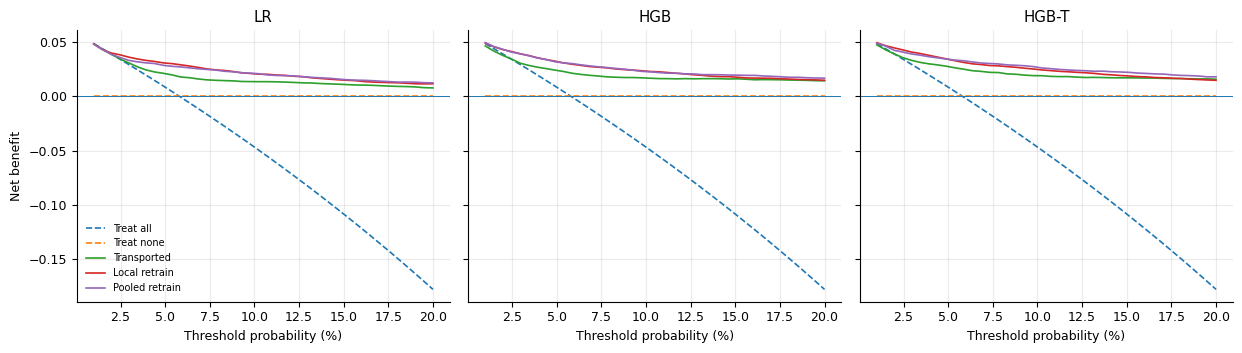

Revised 3-panel DCA tamam ✅
/home/omer/q1_outputs_v2


In [28]:
# ============================================================
# REVIEWER REVISION 3B
# REVISED PATIENT-LEVEL DCA
# Same score definition for septic and non-septic patients:
# maximum risk over ICU stay (max_all)
# Calibration fitted in B_cal, evaluated in B_test
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression


def patient_maxall_arrays(df, p):
    d = df[["patient_id", "SepsisLabel"]].copy()
    d["p"] = np.asarray(p, float)

    pt = d.groupby("patient_id").agg(
        sepsis=("SepsisLabel", "max"),
        max_all=("p", "max")
    )

    return (
        pt["sepsis"].to_numpy().astype(int),
        pt["max_all"].to_numpy(float)
    )


def calibrate_patient_score(
    df_cal,
    p_cal,
    df_test,
    p_test
):
    y_cal_pt, s_cal = patient_maxall_arrays(
        df_cal, p_cal
    )

    y_test_pt, s_test = patient_maxall_arrays(
        df_test, p_test
    )

    recal = LogisticRegression(
        C=1e6,
        max_iter=1000
    )

    recal.fit(
        logit(s_cal).reshape(-1, 1),
        y_cal_pt
    )

    p_test_pt = recal.predict_proba(
        logit(s_test).reshape(-1, 1)
    )[:, 1]

    return y_test_pt, p_test_pt


THR_DCA = np.linspace(
    0.01,
    0.20,
    40
)


def patient_dca(y, predictions):

    y = np.asarray(y).astype(int)
    prev = y.mean()

    out = {
        "threshold": THR_DCA,
        "Treat all": [
            prev - (1-prev) * t/(1-t)
            for t in THR_DCA
        ],
        "Treat none": np.zeros(len(THR_DCA))
    }

    for name, p in predictions.items():
        out[name] = [
            net_benefit(y, p, t)
            for t in THR_DCA
        ]

    return pd.DataFrame(out)


DCA_NEW = {}


# ============================================================
# LR
# ============================================================

y_lr, p_lr_trans = calibrate_patient_score(
    B_cal,
    p_B[cal_idx],
    B_test,
    p_B[test_idx]
)

_, p_lr_local = calibrate_patient_score(
    B_cal,
    LR_LOCAL_CF["cal_oof_raw"],
    B_test,
    LR_LOCAL_CF["test_raw"]
)

_, p_lr_pool = calibrate_patient_score(
    B_cal,
    LR_POOL_CF["cal_oof_raw"],
    B_test,
    LR_POOL_CF["test_raw"]
)

DCA_NEW["LR"] = patient_dca(
    y_lr,
    {
        "Transported": p_lr_trans,
        "Local retrain": p_lr_local,
        "Pooled retrain": p_lr_pool
    }
)


# ============================================================
# HGB
# ============================================================

y_hgb, p_hgb_trans = calibrate_patient_score(
    B_cal,
    p_B_hgb[cal_idx],
    B_test,
    p_B_hgb[test_idx]
)

_, p_hgb_local = calibrate_patient_score(
    B_cal,
    HGB_LOCAL_CF["cal_oof_raw"],
    B_test,
    HGB_LOCAL_CF["test_raw"]
)

_, p_hgb_pool = calibrate_patient_score(
    B_cal,
    HGB_POOL_CF["cal_oof_raw"],
    B_test,
    HGB_POOL_CF["test_raw"]
)

DCA_NEW["HGB"] = patient_dca(
    y_hgb,
    {
        "Transported": p_hgb_trans,
        "Local retrain": p_hgb_local,
        "Pooled retrain": p_hgb_pool
    }
)


# ============================================================
# HGB-T
# ============================================================

y_hgbt, p_hgbt_trans = calibrate_patient_score(
    B_T_cal,
    pT_cal,
    B_T_test,
    pT_test
)

_, p_hgbt_local = calibrate_patient_score(
    B_T_cal,
    HGBT_LOCAL_CF["cal_oof_raw"],
    B_T_test,
    HGBT_LOCAL_CF["test_raw"]
)

_, p_hgbt_pool = calibrate_patient_score(
    B_T_cal,
    HGBT_POOL_CF["cal_oof_raw"],
    B_T_test,
    HGBT_POOL_CF["test_raw"]
)

DCA_NEW["HGB-T"] = patient_dca(
    y_hgbt,
    {
        "Transported": p_hgbt_trans,
        "Local retrain": p_hgbt_local,
        "Pooled retrain": p_hgbt_pool
    }
)


# ============================================================
# FIGURE 5
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(12.5, 3.6),
    sharey=True
)

for ax, model_name in zip(
    axes,
    ["LR", "HGB", "HGB-T"]
):

    D = DCA_NEW[model_name]

    for c in D.columns:

        if c == "threshold":
            continue

        ax.plot(
            D["threshold"] * 100,
            D[c],
            lw=1.2,
            label=c,
            ls="--" if c.startswith("Treat") else "-"
        )

    ax.axhline(
        0,
        linewidth=0.7
    )

    ax.set_title(model_name)
    ax.set_xlabel(
        "Threshold probability (%)"
    )
    ax.grid(alpha=0.25)

axes[0].set_ylabel(
    "Net benefit"
)

axes[0].legend(
    fontsize=7,
    frameon=False
)

fig.tight_layout()

fig.savefig(
    OUT / "fig5_decision_curves_REVISED.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE DATA
# ============================================================

for mdl, D in DCA_NEW.items():

    safe = mdl.replace("-", "")

    D.to_csv(
        OUT / f"dca_REVISED_{safe}.csv",
        index=False
    )

TABLES["dca_REVISED_LR"] = DCA_NEW["LR"]
TABLES["dca_REVISED_HGB"] = DCA_NEW["HGB"]
TABLES["dca_REVISED_HGBT"] = DCA_NEW["HGB-T"]

print("Revised 3-panel DCA tamam ✅")
print(OUT.resolve())